# Diabetes Prediction Model

<a name='1'></a>
# Introduction

The objective of this project is to develop a machine learning model capable of predicting whether an individual is likely to have diabetes based on health and lifestyle indicators. Using data from the Behavioral Risk Factor Surveillance System (BRFSS), provided by the Centers for Disease Control and Prevention and made available through Kaggle, the goal is to transform raw medical and behavioral data into actionable insights.

To simplify the prediction task, the problem is formulated as a binary classification: individuals with prediabetes and no diabetes are grouped into a single class, while confirmed diabetes cases form the second class.


# Table of Contents
* [Introduction](#1)
* [Data Analysing](#2)
* [Data Preprocessing](#3)
* [Model Conception](#4)   
* [Model Training](#5)   
* [Error Analysis](#6)   


<a name='2'></a>

# Data Analysing

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import copy
import matplotlib.pylab as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from codecarbon import EmissionsTracker


plt.style.use('ggplot')
pd.set_option('display.max_columns', 22)

2026-05-03 23:39:38.803983: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-03 23:39:38.885256: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-03 23:39:39.207754: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-03 23:39:39.207850: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-03 23:39:39.270661: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

## Exploratory Data Analysis

To begin, we conducted an exploratory analysis of the available datasets. The project relies on three distinct datasets, each composed of **22 features** describing various health and behavioral indicators.

| Dataset | Observations |
|---|---|
| Dataset 1 | 253,680 |
| Dataset 2 | 70,692 |
| Dataset 3 | 253,680 |

This initial analysis phase aims to better understand the structure, distribution, and consistency of the data across these datasets before proceeding with preprocessing and modeling. Below is a detailed description of each feature:

---

## Feature Descriptions

### Target Variables

| Feature | Description |
|---|---|
| `Diabetes_012` | Three classes: **0** = No Diabetes, **1** = Pre-Diabetes, **2** = Diabetes |
| `Diabetes_binary` | Two classes: **0** = No Diabetes, **1** = Diabetes |

---

### Clinical Indicators

| Feature | Description |
|---|---|
| `HighBP` | Adults who have been told they have high blood pressure by a doctor, nurse, or other health professional |
| `HighChol` | Adults who have ever been told by a health professional that their blood cholesterol is high |
| `CholChk` | Cholesterol check performed within the past five years |
| `BMI` | Body Mass Index |

---

### Lifestyle & Behavioral Factors

| Feature | Description |
|---|---|
| `Smoker` | Has the respondent smoked at least 100 cigarettes in their entire life? |
| `HvyAlcoholConsump` | Heavy drinkers: adult men having more than 14 drinks/week, adult women more than 7 drinks/week |
| `PhysActivity` | Adults who reported doing physical activity or exercise during the past 30 days other than their regular job |
| `Fruits` | Consumes fruit 1 or more times per day |
| `Veggies` | Consumes vegetables 1 or more times per day |

---

### Chronic Health Conditions

| Feature | Description |
|---|---|
| `Stroke` | Has the respondent ever been told they had a stroke? |
| `HeartDiseaseorAttack` | Respondents who have ever reported having coronary heart disease (CHD) or myocardial infarction (MI) |

---

### Healthcare Access

| Feature | Description |
|---|---|
| `AnyHealthcare` | Does the respondent have any kind of health care coverage (insurance, HMO, Medicare, etc.)? |
| `NoDocbcCost` | Was there a time in the past 12 months when the respondent needed to see a doctor but could not due to cost? |

---

### Health Status

| Feature | Description |
|---|---|
| `GenHlth` | Self-reported general health status (scale from 1 = Excellent to 5 = Poor) |
| `MentHlth` | Number of days during the past 30 days when mental health (stress, depression, emotional problems) was not good |
| `PhysHlth` | Number of days during the past 30 days when physical health (illness or injury) was not good |
| `DiffWalk` | Does the respondent have serious difficulty walking or climbing stairs? |

---

### Demographics

| Feature | Description |
|---|---|
| `Sex` | Sex of the respondent |
| `Age` | Fourteen-level age category |
| `Education` | Highest grade or year of school completed |
| `Income` | Annual household income from all sources |

In [2]:
dataset1 = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
dataset2 = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
dataset3 = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")


In [3]:
print(f"Dataset 1{dataset1.shape}")
dataset1

Dataset 1(253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


In [4]:
print(f"Dataset 2{dataset2.shape}")
dataset2

Dataset 2(70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70687,1.0,0.0,1.0,1.0,37.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,4.0,1.0
70688,1.0,0.0,1.0,1.0,29.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,1.0,1.0,10.0,3.0,6.0
70689,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,5.0,15.0,0.0,1.0,0.0,13.0,6.0,4.0
70690,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0


In [5]:
print(f"Dataset 3{dataset3.shape}")
dataset3

Dataset 3(253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


then we check the types of the features in out datasets as you can notice all the columns are of type float:

In [6]:
print(f"Dataset 1 Columns:\n{dataset1.dtypes}\n")
print(f"Dataset 2 Columns:\n{dataset2.dtypes}\n")
print(f"Dataset 3 Columns:\n{dataset3.dtypes}\n")


Dataset 1 Columns:
Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

Dataset 2 Columns:
Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttac

then we check the different columns between the three datasets as you can notice only the first column who represent the diabetes is different and this is because the first dataset have three types (non diabetes, pre-diabetes and with diabetes)

In [7]:
diffrent_column1 = dataset1.columns
diffrent_column2 = dataset2.columns
diffrent_column3 = dataset3.columns

diffrent_column = [column for column in diffrent_column1 if column not in diffrent_column2 or column not in dataset3.columns ]
print(diffrent_column)

['Diabetes_012']


to have a better overview we use a bar chart to see the difference of people with diabetes versus the ones without and for the first dataset we check compare also with people who have pre-diabetes

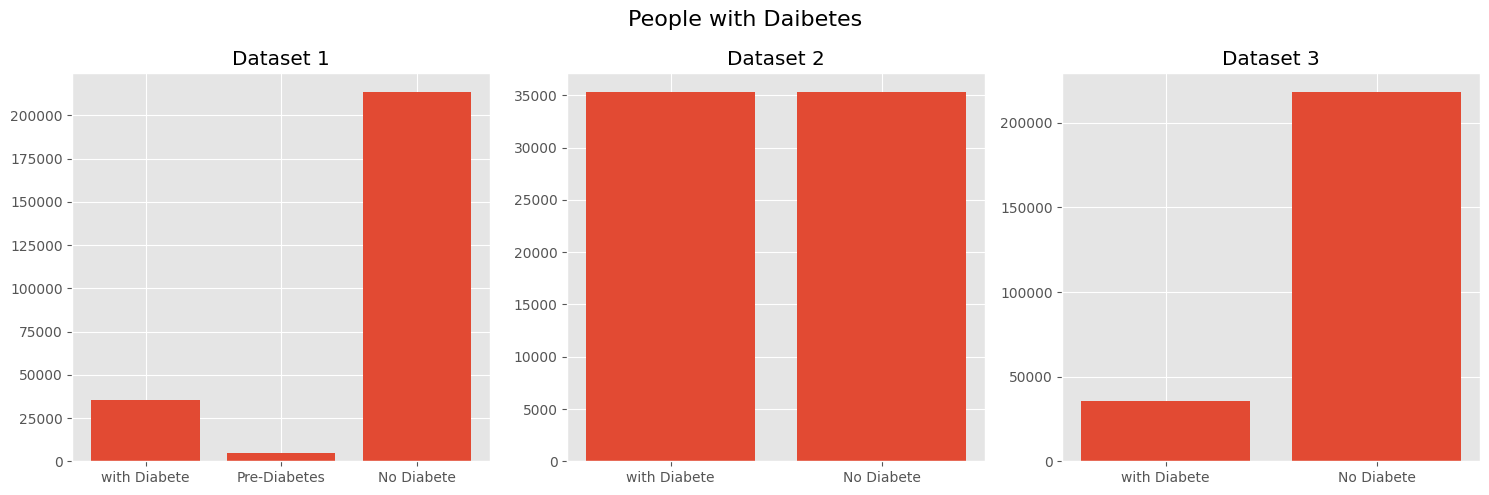

In [8]:
no_diabete1 = dataset1[dataset1['Diabetes_012'] == 0.0]['Diabetes_012']
pre_diabete = dataset1[dataset1['Diabetes_012'] == 1.0]['Diabetes_012']
true_diabete1 = dataset1[dataset1['Diabetes_012'] == 2.0]['Diabetes_012']
y_dataset1 = [len(true_diabete1),len(pre_diabete), len(no_diabete1)]

no_diabete2 = dataset2[dataset2['Diabetes_binary'] == 0.0]['Diabetes_binary']
true_diabete2 = dataset2[dataset2['Diabetes_binary'] != 0.0]['Diabetes_binary']
y_dataset2 = [len(true_diabete2), len(no_diabete2)]

no_diabete3 = dataset3[dataset3['Diabetes_binary'] == 0.0]['Diabetes_binary']
true_diabete3 = dataset3[dataset3['Diabetes_binary'] != 0.0]['Diabetes_binary']
y_dataset3 = [len(true_diabete3), len(no_diabete3)]

dataset1_labels = ["with Diabete","Pre-Diabetes", "No Diabete"]
labels = ["with Diabete", "No Diabete"]


# print(f"Number of people with Diabete: {y_dataset1[0]} \n Number  of people Without Diabete: {y_dataset1[1]}")
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].bar(dataset1_labels, y_dataset1)
ax[0].set_title("Dataset 1")

ax[1].bar(labels, y_dataset2)
ax[1].set_title("Dataset 2")

ax[2].bar(labels, y_dataset3)
ax[2].set_title("Dataset 3")

fig.suptitle("People with Daibetes", fontsize=16)
plt.tight_layout()
plt.show()

we can also check the percentage of man and woman in our dataset also by comapring the one with diabetes and the ones without

Text(0.5, 0.98, 'Male and Female with and without Diabetes')

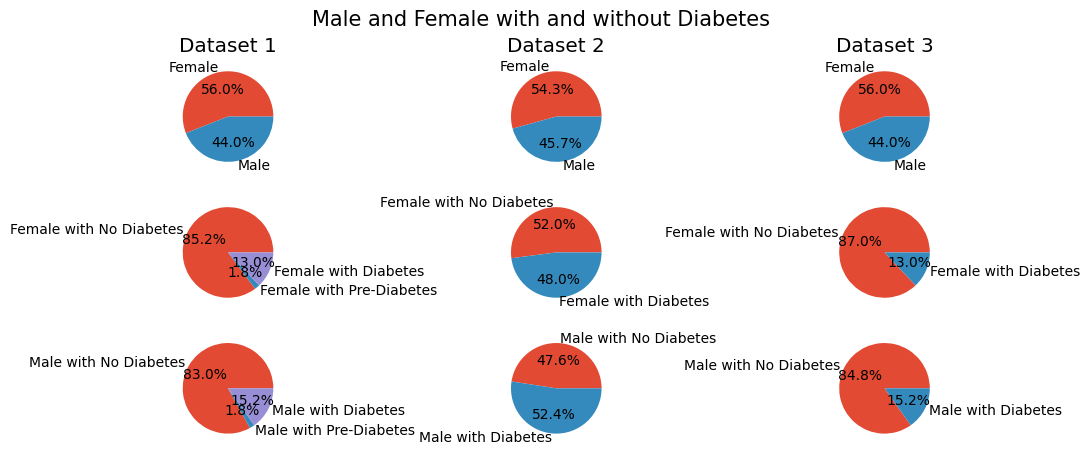

In [9]:
# Male : 1, Female : 0
Female_datset1 = dataset1[dataset1["Sex"]==0.0]["Sex"]
Male_dataset1 = dataset1[dataset1["Sex"]==1.0]["Sex"]
y_pie1 = [len(Female_datset1),len(Male_dataset1)]

Female_datset2 = dataset2[dataset2["Sex"]==0.0]["Sex"]
Male_dataset2 = dataset2[dataset2["Sex"]==1.0]["Sex"]
y_pie2 = [len(Female_datset2),len(Male_dataset2)]


Female_datset3 = dataset3[dataset3["Sex"]==0.0]["Sex"]
Male_dataset3 = dataset3[dataset3["Sex"]==1.0]["Sex"]
y_pie3 = [len(Female_datset3),len(Male_dataset3)]

labels = ["Female", "Male"]

# Male_with_diabetes : 1, Female_with_diabetes : 0
Female_with_no_diabetes_datset1 = dataset1[
    (dataset1["Sex"] == 0.0) & (dataset1["Diabetes_012"] == 0.0)
    ]
Female_with_pre_diabetes_datset1 = dataset1[
    (dataset1["Sex"] == 0.0) & (dataset1["Diabetes_012"] == 1.0)
    ]
Female_with_diabetes_datset1 = dataset1[
    (dataset1["Sex"] == 0.0) & (dataset1["Diabetes_012"] == 2.0)
    ]
y_pie11 = [len(Female_with_no_diabetes_datset1), len(Female_with_pre_diabetes_datset1),len(Female_with_diabetes_datset1)]

labelsdataset1 = ["Female with No Diabetes",  "Female with Diabetes"]
labelsdataset1_2 = ["Female with No Diabetes", "Female with Pre-Diabetes", "Female with Diabetes"]



Female_with_no_diabetes_datset2 = dataset2[
    (dataset2["Sex"] == 0.0) & (dataset2["Diabetes_binary"] == 0.0)
    ]
Female_with_diabetes_datset2 = dataset2[
    (dataset2["Sex"] == 0.0) & (dataset2["Diabetes_binary"] == 1.0)
    ]
y_pie12 = [len(Female_with_no_diabetes_datset2), len(Female_with_diabetes_datset2)]



Female_with_no_diabetes_datset3 = dataset3[
    (dataset3["Sex"] == 0.0) & (dataset3["Diabetes_binary"] == 0.0)
    ]
Female_with_diabetes_datset3 = dataset3[
    (dataset3["Sex"] == 0.0) & (dataset3["Diabetes_binary"] == 1.0)
    ]
y_pie13 = [len(Female_with_no_diabetes_datset3), len(Female_with_diabetes_datset3)]




# Male_with_diabetes : 1, Female_with_diabetes : 0
Male_with_no_diabetes_datset1 = dataset1[
    (dataset1["Sex"] == 1.0) & (dataset1["Diabetes_012"] == 0.0)
    ]
Male_with_pre_diabetes_datset1 = dataset1[
    (dataset1["Sex"] == 1.0) & (dataset1["Diabetes_012"] == 1.0)
    ]
Male_with_diabetes_datset1 = dataset1[
    (dataset1["Sex"] == 1.0) & (dataset1["Diabetes_012"] == 2.0)
    ]
y_pie113 = [len(Male_with_no_diabetes_datset1), len(Male_with_pre_diabetes_datset1),len(Male_with_diabetes_datset1)]



Male_with_no_diabetes_datset2 = dataset2[
    (dataset2["Sex"] == 1.0) & (dataset2["Diabetes_binary"] == 0.0)
    ]
Male_with_diabetes_datset2 = dataset2[
    (dataset2["Sex"] == 1.0) & (dataset2["Diabetes_binary"] == 1.0)
    ]
y_pie123 = [len(Male_with_no_diabetes_datset2), len(Male_with_diabetes_datset2)]



Male_with_no_diabetes_datset3 = dataset3[
    (dataset3["Sex"] == 1.0) & (dataset3["Diabetes_binary"] == 0.0)
    ]
Male_with_diabetes_datset3 = dataset3[
    (dataset3["Sex"] == 1.0) & (dataset3["Diabetes_binary"] == 1.0)
    ]
y_pie133 = [len(Male_with_no_diabetes_datset3), len(Male_with_diabetes_datset3)]


labelsdataset13 = ["Male with No Diabetes",  "Male with Diabetes"]
labelsdataset13_2 = ["Male with No Diabetes", "Male with Pre-Diabetes", "Male with Diabetes"]

fig, axes = plt.subplots(3, 3, figsize=(12, 5))

axes[0, 0].pie(y_pie1, labels=labels, autopct='%1.1f%%')
axes[0, 0].set_title("Dataset 1")

axes[0, 1].pie(y_pie2, labels=labels, autopct='%1.1f%%')
axes[0, 1].set_title("Dataset 2")

axes[0, 2].pie(y_pie3, labels=labels, autopct='%1.1f%%')
axes[0, 2].set_title("Dataset 3")

axes[1, 0].pie(y_pie11, labels=labelsdataset1_2, autopct='%1.1f%%')
axes[1, 1].pie(y_pie12, labels=labelsdataset1, autopct='%1.1f%%')
axes[1, 2].pie(y_pie13, labels=labelsdataset1, autopct='%1.1f%%')

axes[2, 0].pie(y_pie113, labels=labelsdataset13_2, autopct='%1.1f%%')
axes[2, 1].pie(y_pie123, labels=labelsdataset13, autopct='%1.1f%%')
axes[2, 2].pie(y_pie133, labels=labelsdataset13, autopct='%1.1f%%')

fig.suptitle("Male and Female with and without Diabetes", fontsize=15)


<a name='3'></a>

# Data Preprocessing

In this stage, the dataset is prepared for model training through appropriate preprocessing steps. The third dataset is selected, as it contains the same information as the second dataset but in a shuffled order, which helps ensure a more reliable and unbiased training process.

The initial step involves assessing data quality by identifying and handling missing values. Any NaN entries are removed to ensure the dataset is clean, consistent, and suitable for effective model training.

In [10]:
df = dataset3
dataset3.dropna(how="all") # Removing Nan values

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


Then we analyze the relationships between variables using a correlation matrix in order to better understand the dependencies among features. This step helps identify which variables contribute meaningfully to the prediction task and which may have limited relevance.

Based on this analysis, and prior to any feature selection or removal, it is essential to incorporate expert domain knowledge to ensure that important medically relevant variables are not excluded solely based on statistical measures.

We begin by computing the correlation matrix. Before interpreting the results, it is important to understand what a correlation matrix is and how it represents the relationships between features:

The Pearson correlation coefficient measures the **linear relationship**
between two features. It answers: *when feature A goes up, does feature B
tend to go up (positive), go down (negative), or do nothing (zero)?*

The result is always between **-1 and +1**:
- `r = +1` → perfect positive linear relationship
- `r =  0` → no linear relationship
- `r = -1` → perfect negative linear relationship

---

### Step-by-step calculation between two features X and Y

**Step 1 — Compute the mean of each feature:**

$$\bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i \qquad \bar{Y} = \frac{1}{n} \sum_{i=1}^{n} Y_i$$

**Step 2 — Compute the deviations from the mean:**

$$\delta X_i = X_i - \bar{X} \qquad \delta Y_i = Y_i - \bar{Y}$$

**Step 3 — Compute the Pearson correlation coefficient:**

$$r_{XY} = \frac{\sum_{i=1}^{n}(X_i - \bar{X})(Y_i - \bar{Y})}
               {\sqrt{\sum_{i=1}^{n}(X_i - \bar{X})^2} \cdot \sqrt{\sum_{i=1}^{n}(Y_i - \bar{Y})^2}}$$

Which is equivalently written as:

$$r_{XY} = \frac{\text{Cov}(X, Y)}{\sigma_X \cdot \sigma_Y}$$

Where:
- $\text{Cov}(X, Y)$ = covariance between X and Y (how they move together)
- $\sigma_X$ = standard deviation of X (how spread out X is)
- $\sigma_Y$ = standard deviation of Y (how spread out Y is)

The denominator **normalizes** the covariance so the result is always in $[-1, +1]$
regardless of the original scale of X and Y.


### Why a matrix?
For a dataset with $p$ features, pandas computes $r_{XY}$ for **every pair**
of features and arranges the results in a $p \times p$ matrix:

$$\mathbf{R} = \begin{pmatrix}
r_{11} & r_{12} & \cdots & r_{1p} \\
r_{21} & r_{22} & \cdots & r_{2p} \\
\vdots  & \vdots  & \ddots & \vdots  \\
r_{p1} & r_{p2} & \cdots & r_{pp}
\end{pmatrix}$$

Properties of this matrix:
- The **diagonal is always 1** (every feature is perfectly correlated with itself)
- The matrix is **symmetric**: $r_{XY} = r_{YX}$
- This is why we mask the upper triangle — it is identical to the lower triangle

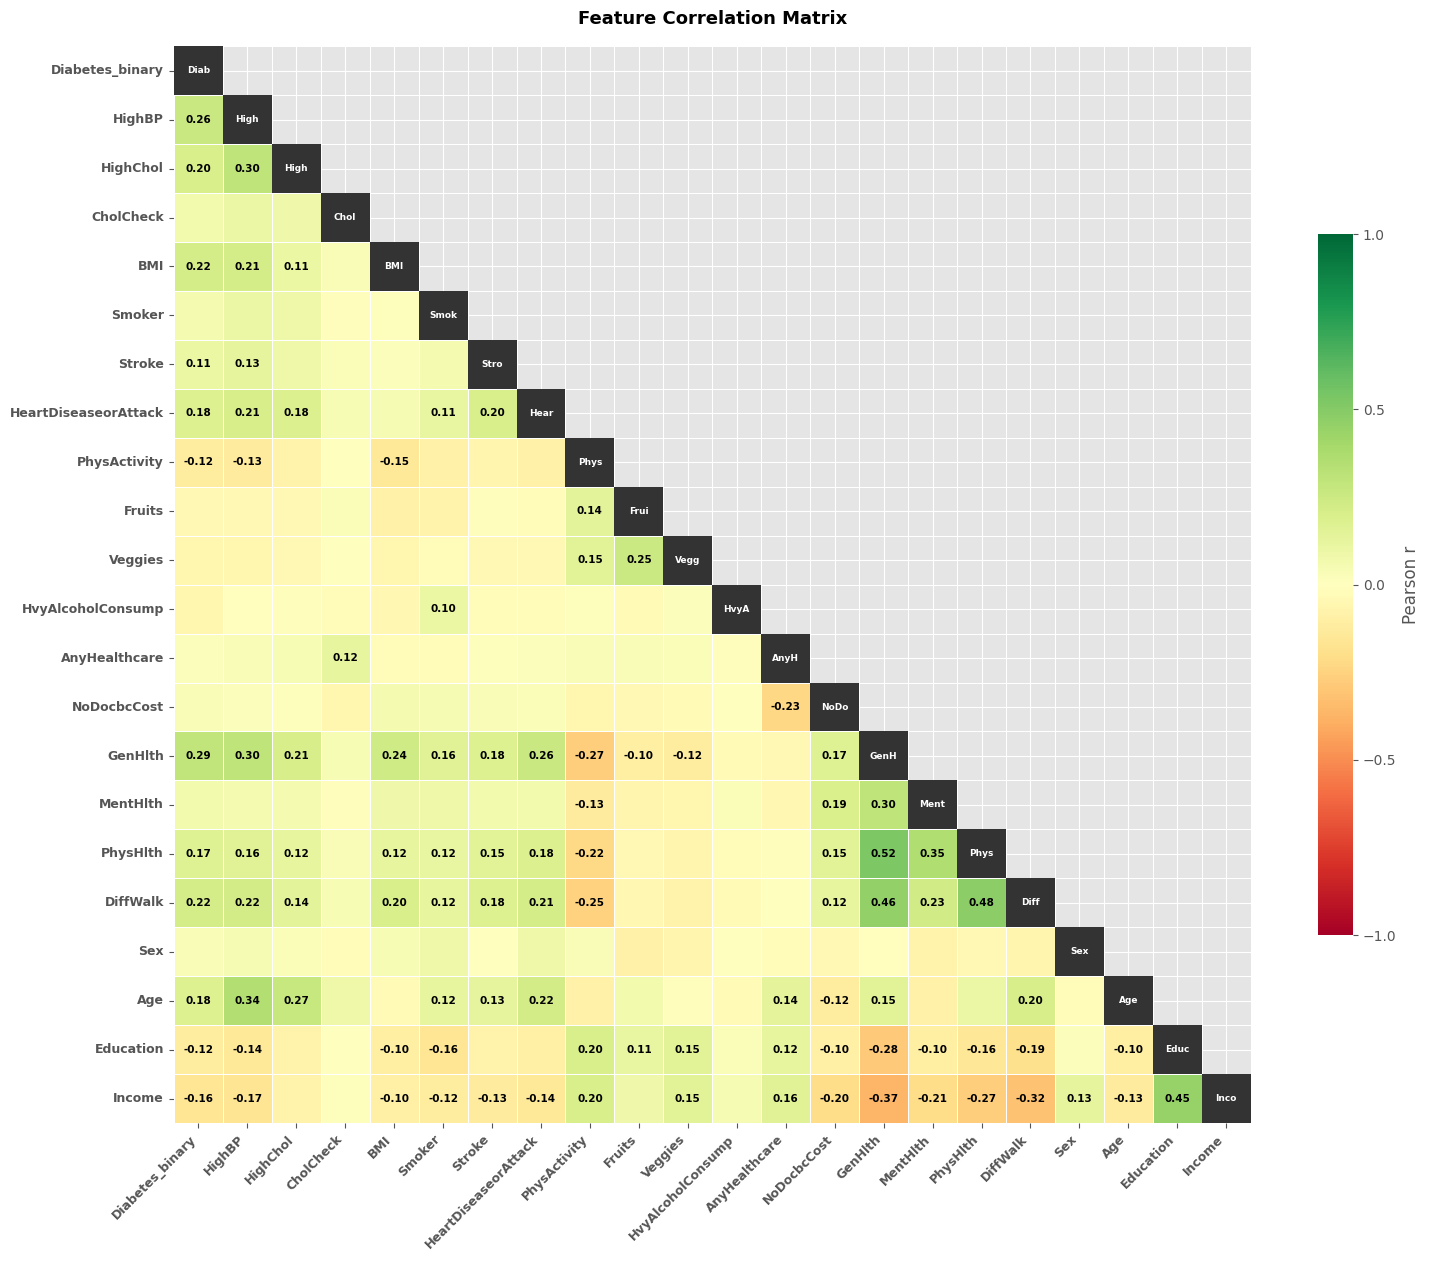

In [11]:
corr_matrix = df.corr()
n = len(corr_matrix)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

cell_size = 0.7                        
fig_size  = max(14, n * cell_size)
fig, ax   = plt.subplots(figsize=(fig_size, fig_size * 0.85))

sns.heatmap(
    corr_matrix,
    mask=mask,
    ax=ax,
    cmap='RdYlGn',           
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.6,
    linecolor='white',
    square=True,
    cbar_kws={
        'shrink': 0.6,
        'label' : 'Pearson r',
        'ticks' : [-1, -0.5, 0, 0.5, 1],
    },
    annot=False,              
)



LABEL_THRESHOLD = 0.10      
for i in range(n):
    for j in range(i):        
        val = corr_matrix.iloc[i, j]
        if abs(val) >= LABEL_THRESHOLD:
            ax.text(
                j + 0.5, i + 0.5,
                f'{val:.2f}',
                ha='center', va='center',
                fontsize=7.5,
                fontweight='bold',
                color='black' if abs(val) < 0.6 else 'white',
            )

            
            
for k in range(n):
    ax.add_patch(plt.Rectangle((k, k), 1, 1, fill=True,
                                color='#333333', lw=0))
    ax.text(k + 0.5, k + 0.5, corr_matrix.columns[k][:4],
            ha='center', va='center', fontsize=6.5,
            color='white', fontweight='bold')

    
    
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right',
                   fontsize=9, fontweight='bold')
ax.set_yticklabels(corr_matrix.columns, rotation=0,
                   fontsize=9, fontweight='bold')
ax.set_title('Feature Correlation Matrix',
             fontsize=13, fontweight='bold', pad=16)

plt.tight_layout()
plt.show()

In [12]:
target_corr = corr_matrix['Diabetes_binary'].drop('Diabetes_binary').abs().sort_values(ascending=False)
print('\n--- Feature correlation with Diabetes_binary ')
print(target_corr.to_string())



--- Feature correlation with Diabetes_binary 
GenHlth                 0.293569
HighBP                  0.263129
DiffWalk                0.218344
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
PhysHlth                0.171337
Income                  0.163919
Education               0.124456
PhysActivity            0.118133
Stroke                  0.105816
MentHlth                0.069315
CholCheck               0.064761
Smoker                  0.060789
HvyAlcoholConsump       0.057056
Veggies                 0.056584
Fruits                  0.040779
NoDocbcCost             0.031433
Sex                     0.031430
AnyHealthcare           0.016255


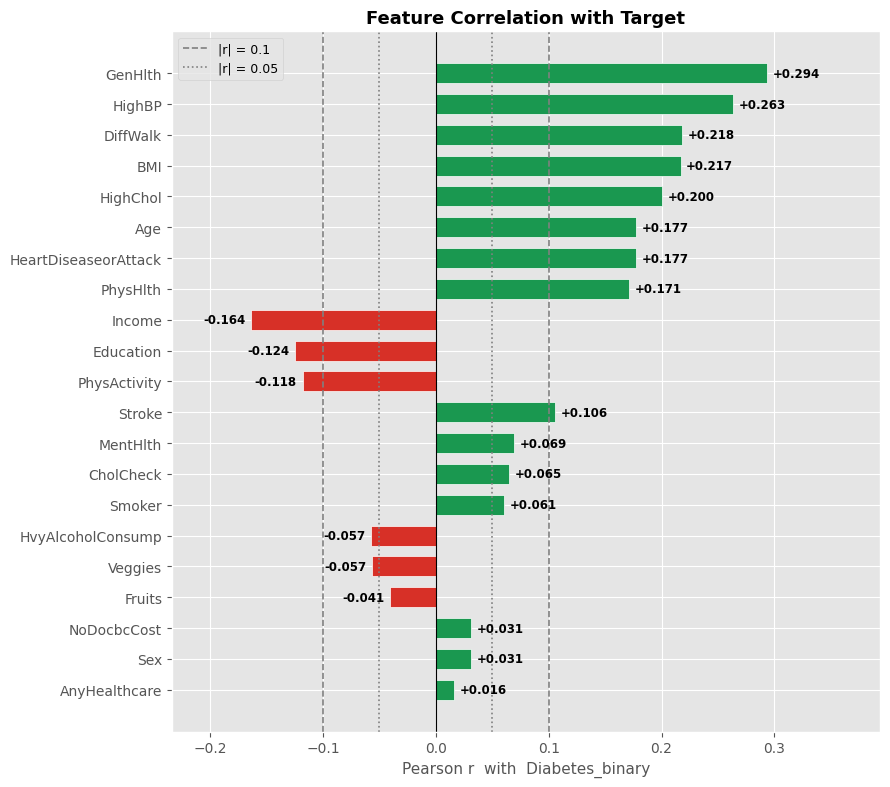

In [13]:
target_corr = (corr_matrix['Diabetes_binary']
               .drop('Diabetes_binary')
               .sort_values(key=abs, ascending=True))  

colors = ['#d73027' if v < 0 else '#1a9850' for v in target_corr]

fig2, ax2 = plt.subplots(figsize=(9, max(6, len(target_corr) * 0.38)))
bars = ax2.barh(target_corr.index, target_corr.values,
                color=colors, edgecolor='white', height=0.65)

# Value labels on each bar
for bar, val in zip(bars, target_corr.values):
    ax2.text(
        val + (0.005 if val >= 0 else -0.005),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=8.5, fontweight='bold',
    )

# Threshold lines
for thresh, style in [(0.10, '--'), (0.05, ':')]:
    ax2.axvline( thresh, color='gray', linestyle=style, linewidth=1.2,
                 label=f'|r| = {thresh}')
    ax2.axvline(-thresh, color='gray', linestyle=style, linewidth=1.2)

ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Pearson r  with  Diabetes_binary', fontsize=11)
ax2.set_title('Feature Correlation with Target',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xlim(target_corr.min() - 0.07, target_corr.max() + 0.10)
plt.tight_layout()
plt.show()

so based on the correlation matrix and Experts advice we will remove the following features : 

Income, Education, Veggies, Fruits

In [14]:
# Columns to drop
df = df.drop(["Income","Education","Veggies","Fruits"], axis=1)
df

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0


Then we need to Normalize the data so that the model can understand the paterns easly.

### Why normalize at all?
Neural networks are sensitive to the **scale** of input features.
Without normalization:
- A feature with large values (e.g. BMI = 45) produces large pre-activations
  → saturates neurons, destabilizes gradients
- Features with large ranges dominate the loss simply due to their units,
  not their actual importance
- Gradient descent converges much slower when features live on different scales

The goal is to bring every feature into a **comparable, bounded range**
before feeding it into the network.

---

## 1. MinMaxScaler

### What it does
Compresses every value to the range $[0, 1]$ by measuring where it sits
between the column minimum and maximum.

### Formula

$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Where:
- $x$ = original value
- $x_{\min}$ = minimum value of the feature **in the training set**
- $x_{\max}$ = maximum value of the feature **in the training set**



### Why fit on train only?

$$x_{\text{test\_scaled}} = \frac{x_{\text{test}} - x_{\min}^{\text{train}}}{x_{\max}^{\text{train}} - x_{\min}^{\text{train}}}$$

The scaler must use the **training set min and max** to transform dev and test.
If you refit on the full dataset:
- The test min/max leak into the scaling parameters
- The model has technically "seen" the test distribution
- Your evaluation metrics become optimistically biased

### Properties
- Output always in $[0, 1]$ **for training data**
- Test values can go slightly outside $[0, 1]$ if they exceed training min/max
- Preserves the original distribution shape (skew is not corrected)
- Sensitive to outliers: one extreme value compresses everything else

---

## 2. log1p Transformation

### What it does
Compresses right-skewed, zero-inflated features using a logarithmic curve.
The `+1` makes it safe for zero values since $\log(0) = -\infty$.

### Formula

$$x_{\text{transformed}} = \log(x + 1) = \ln(x + 1)$$

The inverse (to recover original values) is:

$$x = e^{x_{\text{transformed}}} - 1$$

### Why +1?

$$\log(0 + 1) = \log(1) = 0$$

Zero maps to zero cleanly. Without the `+1`, any patient reporting
0 days of poor mental health would produce $-\infty$.


### What it corrects — distribution shape
```
Before log1p (right-skewed):     After log1p (more uniform):
Count                             Count
  │                                 │
  │█                                │  █
  │█                                │  █  █
  │█                                │  █  █  █
  │█  █                             │  █  █  █  █
  │█  █  █  █  █  █  █              │  █  █  █  █  █  █
   0  5  10 15 20 25 30              0  1  2  3  3.4
```

The extreme spike at 0 flattens, the long tail compresses.
The network now sees a more balanced spread of values.

### Why log1p before MinMaxScaler — order matters

$$x \xrightarrow{\log1p} x' \xrightarrow{\text{MinMax}} x_{\text{final}} \in [0,1]$$

If you applied MinMaxScaler first:
- Values are in $[0, 1]$ but the distribution is still skewed
- Most values are bunched near 0 with a long tail toward 1
- log1p on $[0,1]$ values has very little effect (the range is too small)

Applying log1p **first** gives MinMaxScaler a more uniform distribution
to work with, resulting in a better spread of values across the full $[0,1]$ range.

---

## Summary table

| Feature type | Technique | Why |
|---|---|---|
| Binary (`HighBP`, `Smoker`, etc.) | `clip(0,1).round()` | Guarantee exact {0,1} after oversampling noise |
| Zero-inflated continuous (`MentHlth`, `PhysHlth`) | `log1p` → `MinMaxScaler` | Correct skew first, then scale to [0,1] |
| Ordinal / continuous (`BMI`, `Age`, `GenHlth`, etc.) | `MinMaxScaler` only | Already roughly uniform, just needs rescaling |

In [15]:
# Binary features — guarantee exact {0,1} after any oversampling noise
binary_cols = [
    'HighBP','HighChol','CholCheck','Smoker','Stroke',
    'HeartDiseaseorAttack','PhysActivity','HvyAlcoholConsump',
    'AnyHealthcare','NoDocbcCost','DiffWalk','Sex'
]
binary_cols = [c for c in binary_cols if c in df.columns]
df[binary_cols] = df[binary_cols].clip(0, 1).round()

# Continuous / ordinal features: log-transform zero-inflated ones,
# then MinMax-scale everything to [0, 1].
for col in ['MentHlth', 'PhysHlth']:
    if col in df.columns:
        df[col] = np.log1p(df[col])

CONTINUOUS_FEATURES = ['BMI', 'MentHlth', 'PhysHlth', 'GenHlth', 'Age']
continuous_cols = [c for c in CONTINUOUS_FEATURES if c in df.columns]
scaler = MinMaxScaler()
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])


After Normalizing the Data you can here's the Format of it :

In [16]:
print('\nNormalisation summary ')
print(f'Binary features  ({len(binary_cols)}): {binary_cols}')
print(f'  → clipped & rounded to {{0, 1}}')
print(f'Continuous features ({len(continuous_cols)}): {continuous_cols}')
print(f'  → log1p (MentHlth, PhysHlth) then MinMax scaled to [0, 1]')
print(f'\nValue ranges after normalisation:')
print(df.describe().loc[['min', 'max']].T.to_string())



Normalisation summary 
Binary features  (12): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
  → clipped & rounded to {0, 1}
Continuous features (5): ['BMI', 'MentHlth', 'PhysHlth', 'GenHlth', 'Age']
  → log1p (MentHlth, PhysHlth) then MinMax scaled to [0, 1]

Value ranges after normalisation:
                      min  max
Diabetes_binary       0.0  1.0
HighBP                0.0  1.0
HighChol              0.0  1.0
CholCheck             0.0  1.0
BMI                   0.0  1.0
Smoker                0.0  1.0
Stroke                0.0  1.0
HeartDiseaseorAttack  0.0  1.0
PhysActivity          0.0  1.0
HvyAlcoholConsump     0.0  1.0
AnyHealthcare         0.0  1.0
NoDocbcCost           0.0  1.0
GenHlth               0.0  1.0
MentHlth              0.0  1.0
PhysHlth              0.0  1.0
DiffWalk              0.0  1.0
Sex                   0.0  1.0
Age                   0.0

## Class Imbalance

The diabetes dataset is **imbalanced**: the majority of samples belong to the *no diabetes* class, while diabetic patients are the minority. Training directly on imbalanced data causes the model to be biased toward the majority class  it learns to predict "no diabetes" most of the time, achieving high accuracy but very low recall on the class that actually matters.

The class distribution of our working dataset:

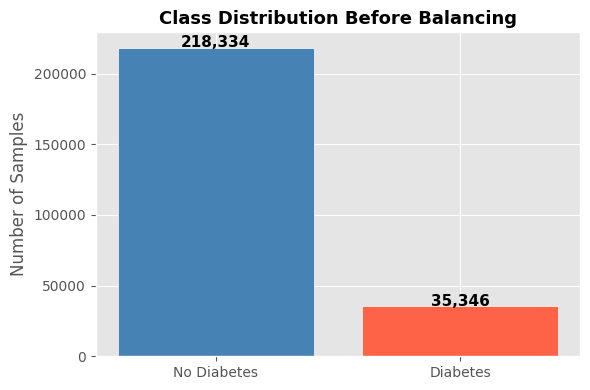

Majority class : 218,334
Minority class : 35,346
Imbalance ratio: 6.18x


In [17]:
labels_map = {0.0: 'No Diabetes', 1.0: 'Diabetes'}
counts = df['Diabetes_binary'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([labels_map[k] for k in counts.index], counts.values,
              color=['steelblue', 'tomato'], edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Class Distribution Before Balancing', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Samples')
plt.tight_layout()
plt.show()

majority = counts.max()
minority = counts.min()
ratio    = majority / minority
print(f"Majority class : {majority:,}")
print(f"Minority class : {minority:,}")
print(f"Imbalance ratio: {ratio:.2f}x")


---

## 1. Random Oversampling

### What it does
Random oversampling addresses the imbalance by **duplicating existing minority-class samples** at random until both classes reach the same size. No new information is created  the same real minority samples are simply repeated.

### How it works
$$N_{\text{minority\new}} = N_{\text{majority}}$$

Minority samples are drawn **with replacement** from the original minority pool and appended to the dataset until the counts are equal.


In [18]:
def apply_random_oversampling(df, target_col='Diabetes_binary', seed=42):
  
    np.random.seed(seed)

    majority_class = df[df[target_col] == 0.0]
    minority_class = df[df[target_col] == 1.0]

    n_to_add = len(majority_class) - len(minority_class)

    minority_oversampled = minority_class.sample(n=n_to_add, replace=True, random_state=seed)

    df_balanced = pd.concat([majority_class, minority_class, minority_oversampled], axis=0)
    df_balanced = df_balanced.sample(frac=1, random_state=seed).reset_index(drop=True)

    print(f"  Original  : Majority: {len(majority_class):,}  |  Minority: {len(minority_class):,}")
    print(f"  Balanced  : Majority: {len(df_balanced[df_balanced[target_col]==0]):,}"
          f"  |  Minority: {len(df_balanced[df_balanced[target_col]==1]):,}")
    print(f"  New dataset size: {len(df_balanced):,}")

    return df_balanced


  Original  : Majority: 218,334  |  Minority: 35,346
  Balanced  : Majority: 218,334  |  Minority: 218,334
  New dataset size: 436,668


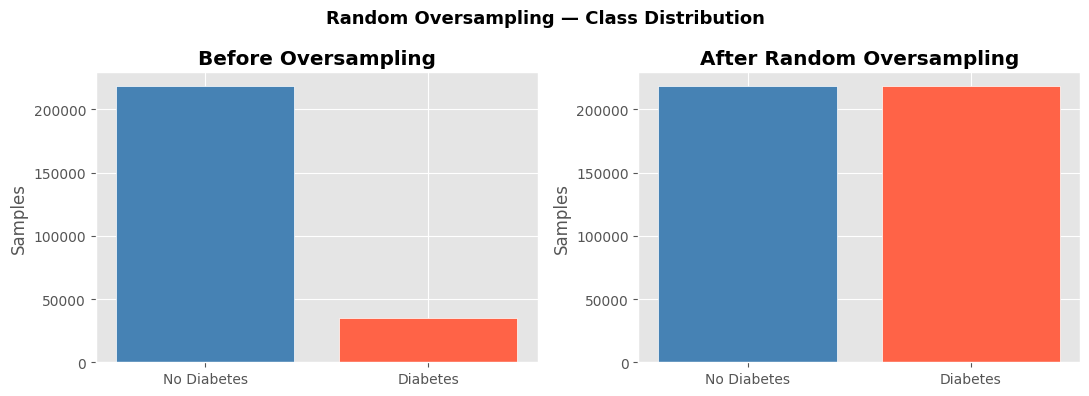

In [19]:
df_oversampled = apply_random_oversampling(df, target_col='Diabetes_binary')

counts_over = df_oversampled['Diabetes_binary'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['No Diabetes', 'Diabetes'],
            df['Diabetes_binary'].value_counts().sort_index().values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Before Oversampling', fontweight='bold')
axes[0].set_ylabel('Samples')

axes[1].bar(['No Diabetes', 'Diabetes'], counts_over.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('After Random Oversampling', fontweight='bold')
axes[1].set_ylabel('Samples')

plt.suptitle('Random Oversampling — Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 2. Random Undersampling

### What it does
Random undersampling balances the dataset by **randomly removing samples from the majority class** until it matches the size of the minority class. The minority class is left completely untouched.

### How it works
$$N_{\text{majority\_new}} = N_{\text{minority}}$$

A random subset of majority-class rows is selected and discarded.


In [20]:
def apply_random_undersampling(df, target_col='Diabetes_binary', seed=42):
   
    np.random.seed(seed)

    majority_class = df[df[target_col] == 0.0]
    minority_class = df[df[target_col] == 1.0]

    # Downsample majority to match minority size
    majority_downsampled = majority_class.sample(n=len(minority_class), replace=False, random_state=seed)

    df_balanced = pd.concat([majority_downsampled, minority_class], axis=0)
    df_balanced = df_balanced.sample(frac=1, random_state=seed).reset_index(drop=True)

    print(f"  Original  : Majority: {len(majority_class):,}  |  Minority: {len(minority_class):,}")
    print(f"  Balanced  : Majority: {len(df_balanced[df_balanced[target_col]==0]):,}"
          f"  |  Minority: {len(df_balanced[df_balanced[target_col]==1]):,}")
    print(f"  New dataset size: {len(df_balanced):,}")
    print(f"  Samples discarded: {len(majority_class) - len(minority_class):,}")

    return df_balanced


  Original  : Majority: 218,334  |  Minority: 35,346
  Balanced  : Majority: 35,346  |  Minority: 35,346
  New dataset size: 70,692
  Samples discarded: 182,988


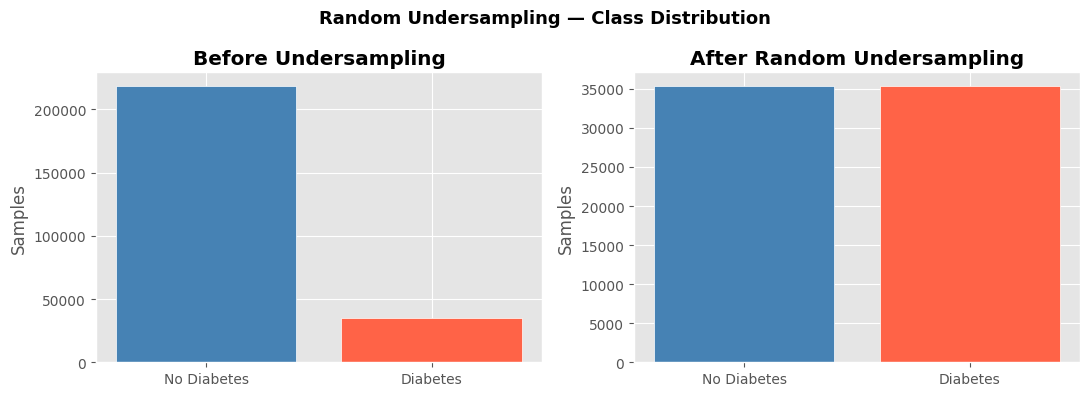

In [21]:
df_undersampled = apply_random_undersampling(df, target_col='Diabetes_binary')

counts_under = df_undersampled['Diabetes_binary'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['No Diabetes', 'Diabetes'],
            df['Diabetes_binary'].value_counts().sort_index().values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Before Undersampling', fontweight='bold')
axes[0].set_ylabel('Samples')

axes[1].bar(['No Diabetes', 'Diabetes'], counts_under.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('After Random Undersampling', fontweight='bold')
axes[1].set_ylabel('Samples')

plt.suptitle('Random Undersampling — Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 4. Class Weighting

### What it does
Class weighting does **not modify the dataset** at all. Instead it tells the loss function to penalise mistakes on the minority class more heavily than mistakes on the majority class. The model is forced to pay more attention to diabetic patients during training.

### How it works
Each sample's contribution to the loss is multiplied by its class weight:

$$\mathcal{L}_{\text{weighted}} = -\frac{1}{m} \sum_{i=1}^{m} w_{y^{(i)}} \left[ y^{(i)} \log\hat{y}^{(i)} + (1-y^{(i)}) \log(1-\hat{y}^{(i)}) \right]$$

The standard **balanced** weighting formula is:

$$w_c = \frac{N_{\text{total}}}{n_{\text{classes}} \times N_c}$$

where $N_c$ is the number of samples in class $c$. This gives the minority class a higher weight and the majority class a lower weight, proportionally.


In [22]:
def compute_class_weights(df, target_col='Diabetes_binary'):
 
    from sklearn.utils.class_weight import compute_class_weight

    classes = np.array([0.0, 1.0])
    weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=df[target_col].values
    )

    class_weight_dict   = {0: weights[0], 1: weights[1]}
    manual_pos_weight   = weights[1] / weights[0]   # used to scale positive-class loss manually

    counts = df[target_col].value_counts().sort_index()
    print(f"  Majority (0 — No Diabetes) : {counts[0]:,}  :  weight = {weights[0]:.4f}")
    print(f"  Minority (1 — Diabetes)    : {counts[1]:,}  :  weight = {weights[1]:.4f}")
    print(f"  Positive / Negative ratio  : {manual_pos_weight:.4f}")
    print(f"  Keras class_weight dict    : {class_weight_dict}")

    return class_weight_dict, manual_pos_weight


  Majority (0 — No Diabetes) : 218,334  :  weight = 0.5809
  Minority (1 — Diabetes)    : 35,346  :  weight = 3.5885
  Positive / Negative ratio  : 6.1770
  Keras class_weight dict    : {0: 0.5809447910082717, 1: 3.5885248684433884}


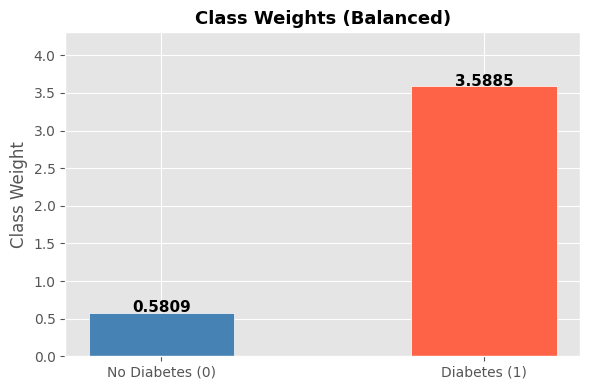

In [23]:
class_weight_dict, manual_pos_weight = compute_class_weights(df, target_col='Diabetes_binary')

labels  = ['No Diabetes (0)', 'Diabetes (1)']
weights = [class_weight_dict[0], class_weight_dict[1]]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, weights, color=['steelblue', 'tomato'], edgecolor='white', width=0.45)
for bar, w in zip(bars, weights):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{w:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Class Weight')
ax.set_title('Class Weights (Balanced)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(weights) * 1.2)
plt.tight_layout()
plt.show()


---

## Summary — Choosing a Balancing Technique

| Technique | Dataset Size After | Risk | Best Use Case |
|---|---|---|---|
| **Random Oversampling** | Larger (duplicates added) | Overfitting on duplicates | Quick baseline, small datasets |
| **Random Undersampling** | Smaller (data discarded) | Information loss | Large datasets, speed priority |
| **Class Weighting** | Unchanged | None on data | Default first attempt, Keras/manual |

The cells below use each balanced dataset (or weight) to re-train the model so you can compare their effect on recall and F1 score.

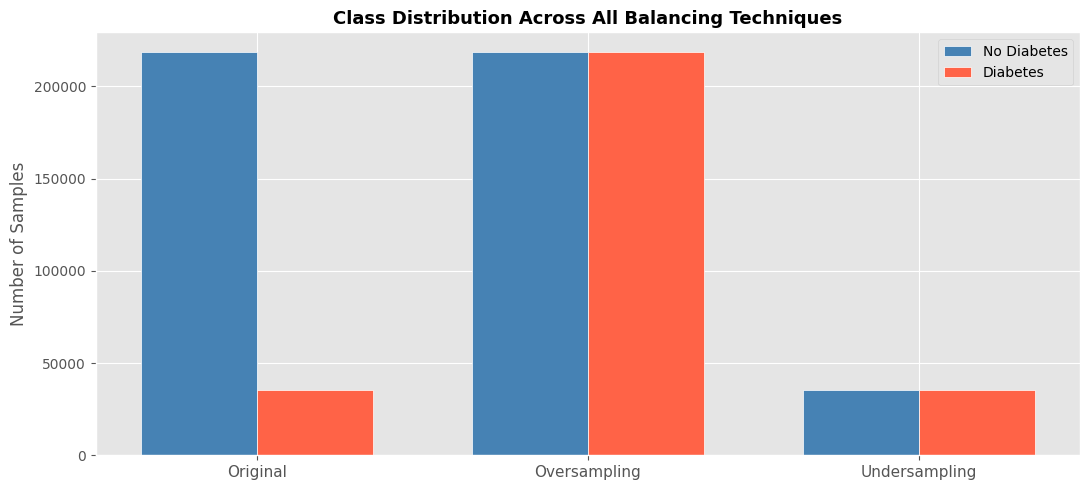

In [24]:
methods = {
    'Original':       df['Diabetes_binary'].value_counts().sort_index().values,
    'Oversampling':   df_oversampled['Diabetes_binary'].value_counts().sort_index().values,
    'Undersampling':  df_undersampled['Diabetes_binary'].value_counts().sort_index().values,
}

x   = np.arange(len(methods))
w   = 0.35
fig, ax = plt.subplots(figsize=(11, 5))

bars0 = ax.bar(x - w/2, [v[0] for v in methods.values()], w,
               label='No Diabetes', color='steelblue', edgecolor='white')
bars1 = ax.bar(x + w/2, [v[1] for v in methods.values()], w,
               label='Diabetes',    color='tomato',    edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(methods.keys(), fontsize=11)
ax.set_ylabel('Number of Samples')
ax.set_title('Class Distribution Across All Balancing Techniques', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


<a name='4'></a>

# Model Conception 

After preprocessing and cleaning the data, we begin the training phase. To do so, we first implement the model manually by defining its layers and corresponding activation functions. In order to validate each step of the implementation and ensure correctness, we initially train the model on a small dataset (the one used in the prosit).

Subsequently, we replicate the same architecture and hyperparameters using the Keras library. This allows us to compare the performance of our custom implementation with a standardized framework. Additionally, we initialize both models with identical weights and biases to ensure a fair comparison, enabling us to verify whether they converge to the same values—whether at a local or, less likely, global minimum.

## Testing Manual model

Here we compare the results of the two models on the Prosit2 datasets so we can check if the manual model is right.

First here's the configuration of the models parameters and hyperparameters

**Used Optimizer :** gradient decent Default SGD in keras

**leraning rate :** 0.01

**Layers architecture :** [21, 64, 1]

**Number of iterations :** 1000

### Results : 

Manual Model : 
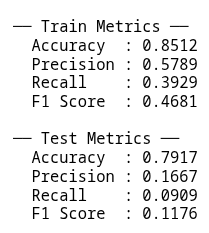
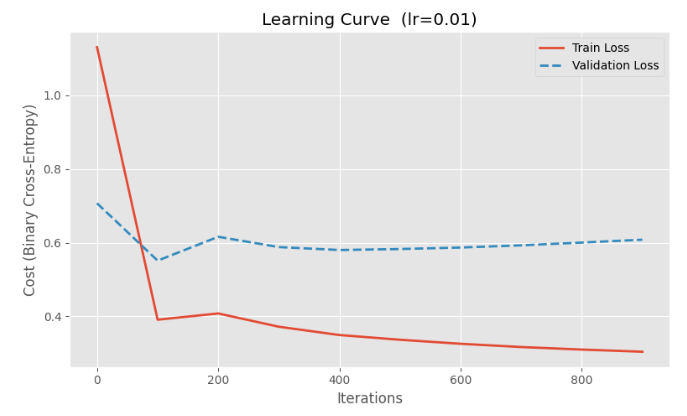

Keras Model : 
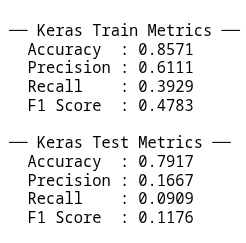
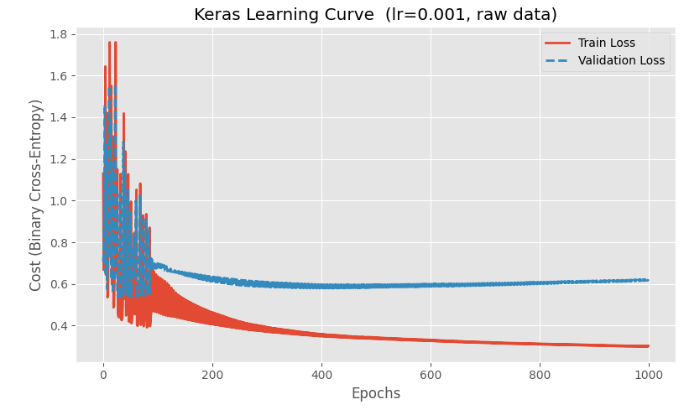 

### Difference Between Models : 
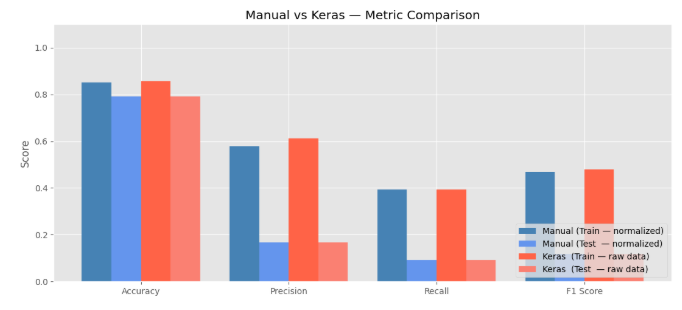

In [25]:
def load_testing_data(df) :
    
    dataset = np.array(df)
    
    np.random.seed(42)
    indices = np.random.permutation(240)
    
    train_size = int(0.7 * 240) # 70% of the dataset
    test_size = 240 - train_size # 30% of the dataset
        
    
    train_set = dataset[indices[:train_size]]
    test_set = dataset[indices[train_size:]]
    
    
    # selecting the Label 
    X_train = np.array(train_set[:, 1:]).T
    Y_train = np.array(train_set[:, 0])
    
    X_test = np.array(test_set[:, 1:]).T
    Y_test = np.array(test_set[:, 0])
    
    Y_train = Y_train.reshape(1, -1)    
    Y_test = Y_test.reshape(1, -1)     
    

    print(f"X_train: {X_train.shape}")
    print(f"Y_train: {Y_train.shape}")
    print(f"X_test: {X_test.shape}")
    print(f"Y_test: {Y_test.shape}")

    return  X_train, X_test, Y_train, Y_test

## Dataset Splitting

Before training, the full dataset is randomly shuffled and divided into **three non-overlapping subsets**:

| Split | Proportion | Purpose |
|-------|-----------|---------|
| **Training set** | 60 % | The model learns from this data - weights and biases are updated on it |
| **Validation set (Dev)** | 20 % | Used during training to monitor generalisation and tune hyperparameters, but never used for weight updates |
| **Test set** | 20 % | Held out entirely until final evaluation - gives an unbiased estimate of real-world performance |

Using three splits instead of two prevents *information leakage*: because the test set is never seen during training or tuning, the final accuracy score reflects true generalisation rather than memorisation.

In [26]:
def load_dataset(df):
    dataset = np.array(df, dtype=np.float64)

    np.random.seed(42)
    indices = np.random.permutation(len(dataset))

    n        = len(dataset)
    train_size = int(0.60 * n)          # 60%
    val_size   = int(0.20 * n)          # 20%
    # remaining 20% goes to test

    train_set = dataset[indices[:train_size]]
    val_set   = dataset[indices[train_size : train_size + val_size]]
    test_set  = dataset[indices[train_size + val_size :]]

    X_train = train_set[:, 1:].T          # (features, samples)
    Y_train = train_set[:, 0].reshape(1, -1)

    X_dev   = val_set[:, 1:].T
    Y_dev   = val_set[:, 0].reshape(1, -1)

    X_test  = test_set[:, 1:].T
    Y_test  = test_set[:, 0].reshape(1, -1)

    print(f'X_train : {X_train.shape}  |  Y_train : {Y_train.shape}')
    print(f'X_dev   : {X_dev.shape}    |  Y_dev   : {Y_dev.shape}')
    print(f'X_test  : {X_test.shape}   |  Y_test  : {Y_test.shape}')

    return X_train, X_dev, X_test, Y_train, Y_dev, Y_test


## Weight Initialisation 

### Why initialisation matters
If all weights are set to zero or to the same constant, every neuron in a layer computes the same gradient and the network fails to break symmetry — it effectively trains as a single neuron no matter how many layers it has.
Initialising with random values breaks this symmetry, but the *scale* of those values is critical:

* **Too large** → pre-activations explode → saturated neurons → **vanishing / exploding gradients**
* **Too small** → activations shrink to zero layer by layer → gradients vanish → weights stop updating

### He Initialisation (Kaiming, 2015)
He initialisation is specifically designed for layers followed by a **ReLU** activation. It sets the variance of each weight matrix so that the signal magnitude is preserved on average across the forward pass:

$$W^{[l]} \sim \mathcal{N}\!\left(0,\; \frac{2}{n^{[l-1]}}\right)$$

In practice this is implemented as:

$$W^{[l]} = \texttt{randn}(n^{[l]},\; n^{[l-1]}) \;\times\; \sqrt{\frac{2}{n^{[l-1]}}}$$

where:
* $n^{[l-1]}$ is the number of neurons in the **previous** layer (fan-in)
* $n^{[l]}$ is the number of neurons in the **current** layer

The factor $\sqrt{2 / n^{[l-1]}}$ compensates for the fact that ReLU sets roughly half of its inputs to zero, which would otherwise halve the effective variance at each layer. Biases are initialised to **zero** — a safe default since the weight asymmetry already breaks symmetry.

> **Result:** gradients remain well-scaled throughout the network, enabling stable and fast convergence even in deep architectures.

In [27]:
def intialization(Layers):
#     print(X_train.shape)
#     print(X_test.shape)
#     print(Y_train.shape)
#     print(Y_test.shape)

    params = {}
    
    for l in range(1, len(Layers)): 
        params["W" + str(l)] = np.random.randn(Layers[l], Layers[l-1]) * np.sqrt(2/Layers[l-1])
        params["b" + str(l)] = np.zeros((Layers[l], 1)) 
        
    
    print(params["W1"].shape)
    print(params["b1"].shape)

    return params

## Activation Functions

Activation functions introduce **non-linearity** into the network. Without them, stacking multiple layers would collapse into a single linear transformation, making depth pointless.

---

### Sigmoid  $\sigma(Z)$

$$\sigma(Z) = \frac{1}{1 + e^{-Z}}$$

The sigmoid function squashes any real number into the range $(0, 1)$, making its output directly interpretable as a **probability**.

**Why we use it on the output layer:**  
This is a binary classification problem (Diabetes: yes / no). The network must output a value between 0 and 1 that represents the probability of belonging to the positive class. Sigmoid is the natural choice because:
- Its output range $(0,1)$ matches the probability scale exactly
- Thresholding at 0.5 gives a hard class prediction
- It pairs naturally with the **Binary Cross-Entropy** loss

In [28]:
def sigmoid(Z):
    cache = Z
    return 1/(1+np.exp(-Z)), cache

---

### ReLU  (Rectified Linear Unit)

$$\text{ReLU}(Z) = \max(0,\; Z)$$

ReLU is used on all **hidden layers**. Its advantages over sigmoid/tanh in hidden layers are:
- **No vanishing gradient** for positive inputs — the gradient is exactly 1, so it flows unchanged through the layer
- **Sparse activations** — negative inputs are zeroed out, reducing co-adaptation between neurons
- **Computationally cheap** — just a threshold operation

The combination of **ReLU in hidden layers + Sigmoid on the output layer** is the standard architecture for binary classification networks.

In [29]:
def relu(Z):
    cache = Z
    return np.maximum(0, Z), cache

In [30]:
def forward_propagation(W, b, A):
    Z = W @ A + b
    cache = (W, A, b)
    return Z, cache

In [31]:
def linear_activation_forward(W, b, activation, A_prev):
    
    if activation == "sigmoid":
        Z, linear_cache = forward_propagation(W, b, A_prev)
        A, activation_cache = sigmoid(Z)
            
    elif activation == "relu":
        Z, linear_cache = forward_propagation(W, b, A_prev)
        A, activation_cache = relu(Z)
    
    cache = (linear_cache, activation_cache)
    return A, cache    

---

## Forward Propagation 

Forward propagation passes the input $X$ through every layer of the network from left to right, computing the activations step by step until the final prediction $\hat{Y} = A^{[L]}$ is produced.

For each layer $l$, two operations are performed:

**1. Linear step:**
$$Z^{[l]} = W^{[l]} A^{[l-1]} + b^{[l]}$$

**2. Activation step:**
$$A^{[l]} = g^{[l]}(Z^{[l]})$$

where $g^{[l]}$ is ReLU for hidden layers and Sigmoid for the output layer.

All intermediate values $(W, A_{\text{prev}}, b, Z)$ are saved in a **cache** list. These cached values are essential for backpropagation, which needs them to compute gradients efficiently without recomputing forward passes.

In [32]:
def L_model_forward(X, params):
    caches = []
    L = len(params) // 2
    A = X
    
    for l in range(1, L):
        A_prev = A
        A, cache = linear_activation_forward(params["W" + str(l)], params["b" + str(l)], "relu", A_prev)
        caches.append(cache)
        
    AL, cache = linear_activation_forward(params["W" + str(L)], params["b" + str(L)], "sigmoid", A)
    caches.append(cache)
    
    return AL, caches


---

## Cost Function (Binary Cross-Entropy)

The cost function measures how far the network's predictions $\hat{Y} = A^{[L]}$ are from the true labels $Y$. It is the single scalar we want to **minimise** during training.

For binary classification we use **Binary Cross-Entropy (Log Loss)**:

$$\mathcal{L}(Y, \hat{Y}) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log\hat{y}^{(i)} + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

where:
* $m$ is the number of training examples
* $y^{(i)} \in \{0, 1\}$ is the true label
* $\hat{y}^{(i)} \in (0, 1)$ is the predicted probability

**Intuition:**
- When $y=1$, the loss penalises $\hat{y}$ being close to 0 (confident wrong prediction)
- When $y=0$, the loss penalises $\hat{y}$ being close to 1
- A perfect prediction ($\hat{y} = y$) contributes zero loss

The implementation clips $\hat{y}$ to $(10^{-8},\; 1-10^{-8})$ to avoid $\log(0) = -\infty$.

In [33]:
def cost_function(Y, AL, pos_weight=1.0):
    m = Y.shape[1]
    AL = np.clip(AL, 1e-8, 1 - 1e-8)  # prevent log(0)
    
    # if you want to use class weighting uncomment the following comment 
    cost = -1/m * np.sum(pos_weight * Y * np.log(AL) + (1-Y) * np.log(1-AL))

    cost = np.squeeze(cost)
    return cost


---

## Backward Propagation

Backpropagation applies the **chain rule** of calculus in reverse  from the output layer back to the input  to compute the gradient of the cost $\mathcal{L}$ with respect to every weight and bias in the network. These gradients tell us in which direction (and by how much) to adjust each parameter to reduce the loss and move closer to the **global minimum**.

The backward pass mirrors the forward pass exactly: for every layer we un-do the activation step then the linear step.

---

### `relu_backward`

The gradient of ReLU is a simple gate:

$$\frac{\partial \mathcal{L}}{\partial Z} = \begin{cases} \frac{\partial \mathcal{L}}{\partial A} & \text{if } Z > 0 \\ 0 & \text{if } Z \leq 0 \end{cases}$$

Neurons that were inactive (Z ≤ 0) contribute **zero gradient**, preventing the error signal from flowing through them. Neurons that were active pass the gradient through unchanged.

In [34]:
def relu_backward(cache, dA):
    Z = cache
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    
    assert (dZ.shape == Z.shape)

    
    return dZ

---

### `sigmoid_backward`

The derivative of the sigmoid function has a convenient closed form:

$$\frac{d\sigma}{dZ} = \sigma(Z)\,(1 - \sigma(Z))$$

So the gradient flowing back through the output activation is:

$$\frac{\partial \mathcal{L}}{\partial Z^{[L]}} = \frac{\partial \mathcal{L}}{\partial A^{[L]}} \cdot \sigma(Z^{[L]})\,(1 - \sigma(Z^{[L]}))$$

In [35]:
def sigmoid_backward(cache, dA):
    Z = cache
    s = 1/(1+np.exp(-Z))
    dZ = dA * s * (1-s)
    
    assert (dZ.shape == Z.shape)
    
    return dZ

---

### `linear_backward`

Once we have $dZ^{[l]}$, we compute the three gradients needed to update the layer's parameters and propagate the error further back:

$$dW^{[l]} = \frac{1}{m}\, dZ^{[l]}\, (A^{[l-1]})^\top$$

$$db^{[l]} = \frac{1}{m}\, \sum dZ^{[l]}$$

$$dA^{[l-1]} = (W^{[l]})^\top\, dZ^{[l]}$$

* $dW$ and $db$ are used to **update the parameters** of this layer
* $dA^{[l-1]}$ is passed back to the previous layer to continue the chain

In [36]:
def linear_backward(dZ, cache):
    linear_cache, activation_cache = cache
    W, A_prev, b  = linear_cache
    m = A_prev.shape[1]
    dW =1/m*np.dot(dZ, A_prev.T)
    db = 1/m*np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T, dZ)
    
    return dA_prev, dW, db
    

In [37]:
def linear_activation_backward(dA, cache, activation):
    linear_cache, activation_cache = cache
    if activation == "relu":
        dZ = relu_backward(activation_cache, dA)      # FIX 4a: pass activation_cache (Z), not full cache
        dA_prev, dW, db = linear_backward(dZ, cache)
    
    elif activation == "sigmoid":
        dZ = sigmoid_backward(activation_cache, dA)   # FIX 4b: pass activation_cache (Z), not full cache
        dA_prev, dW, db = linear_backward(dZ, cache)
        
    return dA_prev, dW, db


---

###  Full Backward Pass

This function orchestrates the complete backward pass over all $L$ layers. It starts from the cost gradient with respect to the final output:

$$dA^{[L]} = -\frac{Y}{\hat{Y}} + \frac{1-Y}{1-\hat{Y}}$$

Then it loops backwards through the layers:
1. **Output layer** → sigmoid backward + linear backward
2. **Hidden layers** → ReLU backward + linear backward (repeated for $l = L-1, \ldots, 1$)

All gradients $dW^{[l]}$ and $db^{[l]}$ are collected in a `grads` dictionary that is passed to the parameter update step.

In [38]:
def L_model_backward(AL, caches, Y, pos_weight =1.0):
    grads = {}
    L = len(caches)
    m = AL.shape[1]
    Y = Y.reshape(AL.shape)

    AL = np.clip(AL, 1e-8, 1 - 1e-8)  # prevent divide by zero in gradient 
    dAL = -np.divide(pos_weight * Y, AL) + np.divide((1-Y), (1-AL))
    
    current_cache = caches[L-1]
    dA_prev_temp, dW_temp, db_temp = linear_activation_backward(dAL, current_cache, activation="sigmoid")
    grads["dA" + str(L)] = dA_prev_temp
    grads["dW" + str(L)] = dW_temp
    grads["db" + str(L)] = db_temp

    for l in reversed(range(L-1)):
        current_cache = caches[l]
        dA_prev_temp, dW_temp, db_temp = linear_activation_backward(dA_prev_temp, current_cache, activation="relu")
        grads["dA" + str(l+1)] = dA_prev_temp
        grads["dW" + str(l+1)] = dW_temp
        grads["db" + str(l+1)] = db_temp

    return grads


---

## Parameter Update  Gradient Descent

With the gradients computed, we update every weight and bias using the **Gradient Descent** rule:

$$W^{[l]} := W^{[l]} - \alpha \cdot dW^{[l]}$$

$$b^{[l]} := b^{[l]} - \alpha \cdot db^{[l]}$$

where $\alpha$ is the **learning rate**  a hyperparameter that controls the step size.

**Why this works:**  
The gradient $dW^{[l]}$ points in the direction of *steepest ascent* of the cost surface. Subtracting it moves the parameters in the direction of *steepest descent*, reducing the cost. Repeating this process over many iterations guides the parameters towards the **global minimum** of the loss landscape, which corresponds to the best possible predictions the network can make.

In [39]:
def update_paramters(params, grads, learning_rate):
    
    L = len(params) // 2
    parameters = copy.deepcopy(params)
    
    for l in range(L):
        parameters["W" + str(l+1)] =  parameters["W" + str(l+1)] - learning_rate * grads["dW" + str(l+1)]
        parameters["b" + str(l+1)] =  parameters["b" + str(l+1)] - learning_rate * grads["db" + str(l+1)]
  
    return parameters

## Mini-Batches

Mini-batch processing is a technique that consists of dividing the dataset into equally sized subsets of examples. Instead of processing the entire dataset at once, the model iterates over these smaller batches sequentially. This approach improves computational efficiency, accelerates convergence, and optimizes the overall training process.

In [40]:
def create_mini_batches(X, Y, batch_size, seed=0):

    np.random.seed(seed)
    m = X.shape[1]                          # number of training samples
    mini_batches = []

    # Shuffle columns (samples) together
    perm = np.random.permutation(m)
    X_shuffled = X[:, perm]
    Y_shuffled = Y[:, perm]

    # Use full batch if batch_size is None or >= m
    effective_bs = m if (batch_size is None or batch_size >= m) else batch_size

    num_complete = m // effective_bs
    for k in range(num_complete):
        mb_X = X_shuffled[:, k*effective_bs : (k+1)*effective_bs]
        mb_Y = Y_shuffled[:, k*effective_bs : (k+1)*effective_bs]
        mini_batches.append((mb_X, mb_Y))

    # Last incomplete mini-batch (if any)
    if m % effective_bs != 0:
        mb_X = X_shuffled[:, num_complete*effective_bs:]
        mb_Y = Y_shuffled[:, num_complete*effective_bs:]
        mini_batches.append((mb_X, mb_Y))

    return mini_batches

## Gradient Descent Momentum

Gradient Descent with Momentum is an optimization technique designed to improve convergence when searching for an optimal solution. It incorporates information from previous gradients to smooth parameter updates and reduce oscillations during training. The direction and magnitude of past gradients are accumulated in a variable v, which represents an exponentially weighted average of previous updates.

This concept can be intuitively understood as the “velocity” of a ball rolling downhill, where the accumulated momentum allows it to build speed and maintain a consistent direction based on the slope of the loss function.

In [41]:
def initialize_velocity(parmeters):
    L = len(parameters)//2
    v = {}
    
    for l in range(1,  L + 1):
        v["dW" + str(l)] = np.zeros(parameters['W' + str(l)].shape)
        v["db" + str(l)] = np.zeros(parameters['b' + str(l)].shape)
    return v

In [42]:
def update_parameters_with_momentum(parameters, grads, v, beta, learning_rate):
    L = len(parameters) // 2
    
    for l in range(1, L + 1):
        v["dW" + str(l)] = beta * v["dW" + str(l)] + (1-beta)*grads["dW" + str(l)]
        parameters["W" + str(l)] = parameters["W" +str(l)] - learning_rate * v["dW" + str(l)]
        v["db" + str(l)] = beta * v["db" + str(l)] + (1-beta)*grads["db" + str(l)]
        parameters["b" + str(l)] = parameters["b" + str(l)] - learning_rate * v["db" + str(l)]
        
    return parameters, v

## Adam 


Adam is one of the most effective optimization algorithms for training neural networks. It combines ideas from RMSProp and Momentum. 

**How does Adam work?**
1. It calculates an exponentially weighted average of past gradients, and stores it in variables $v$ (before bias correction) and $v^{corrected}$ (with bias correction). 
2. It calculates an exponentially weighted average of the squares of the past gradients, and  stores it in variables $s$ (before bias correction) and $s^{corrected}$ (with bias correction). 
3. It updates parameters in a direction based on combining information from "1" and "2".

The update rule is, for $l = 1, ..., L$: 
# $$\begin{cases}
v_{dW^{[l]}} = \beta_1 v_{dW^{[l]}} + (1 - \beta_1) \frac{\partial \mathcal{J} }{ \partial W^{[l]} } \\
v^{corrected}_{dW^{[l]}} = \frac{v_{dW^{[l]}}}{1 - (\beta_1)^t} \\
s_{dW^{[l]}} = \beta_2 s_{dW^{[l]}} + (1 - \beta_2) (\frac{\partial \mathcal{J} }{\partial W^{[l]} })^2 \\
s^{corrected}_{dW^{[l]}} = \frac{s_{dW^{[l]}}}{1 - (\beta_2)^t} \\
W^{[l]} = W^{[l]} - \alpha \frac{v^{corrected}_{dW^{[l]}}}{\sqrt{s^{corrected}_{dW^{[l]}}} + \varepsilon}
\end{cases}$$
where:
- t counts the number of steps taken of Adam 
- L is the number of layers
- $\beta_1$ and $\beta_2$ are hyperparameters that control the two exponentially weighted averages. 
- $\alpha$ is the learning rate
- $\varepsilon$ is a very small number to avoid dividing by zero


In [43]:
def initialize_adam(parameters):
    L = len(parameters) // 2
    v = {}
    s = {}
    
    for l in range(1, L+1):
        v["dW" + str(l)] = np.zeros(parameters["W" + str(l)].shape)
        v["db" + str(l)] = np.zeros(parameters["b" + str(l)].shape)
        s["dW" + str(l)] = np.zeros(parameters["W" + str(l)].shape)
        s["db" + str(l)] = np.zeros(parameters["b" + str(l)].shape)
        
    return v, s

In [44]:
def update_parameters_with_adam(parameters, grads, v, s, t, learning_rate, beta1 = 0.9, beta2 = 0.999, epsilon = 1e-8):
    L = len(parameters) // 2
    v_corrected = {}
    s_corrected = {}
    
    for l in range(1, L + 1):
        # Gradient Decent Momentum
        v["dW" + str(l)] = beta1 * v["dW" + str(l)] + (1 - beta1) * grads["dW" + str(l)]
        v["db" + str(l)] = beta1 * v["db" + str(l)] + (1 - beta1) * grads["db" + str(l)]
       
        v_corrected["dW" + str(l)] = v["dW" + str(l)] / (1 - beta1**t)
        v_corrected["db" + str(l)] = v["db" + str(l)] / (1 - beta1**t)
        
        # RMSPrompt
        s["dW" + str(l)] = beta2 * s["dW" + str(l)] + (1 - beta2) * np.square(grads["dW" + str(l)])  
        s["db" + str(l)] = beta2 * s["db" + str(l)] + (1 - beta2) * np.square(grads["db" + str(l)])  
        
        s_corrected["dW" + str(l)] = s["dW" + str(l)] / (1 - beta2**t)
        s_corrected["db" + str(l)] = s["db" + str(l)] / (1 - beta2**t)
        
        
        # Adam
        parameters["W" + str(l)] = parameters["W" + str(l)] - learning_rate * (v_corrected["dW" + str(l)] / (np.sqrt(s_corrected["dW" + str(l)]) + epsilon))
        parameters["b" + str(l)] = parameters["b" + str(l)] - learning_rate * (v_corrected["db" + str(l)] / (np.sqrt(s_corrected["db" + str(l)]) + epsilon))
    
    return parameters, v, s, v_corrected, s_corrected                                                                   

## Gradient Checking 

The Gradient Checking consist in using  the Symmetric Derivative to check if the gradient are well calculated during the backpropagation.

**How does gradient checking work?**

we want to compare "gradapprox" to the gradient computed by backpropagation. The formula is :

$$ \frac{\partial J}{\partial \theta} = \lim_{\varepsilon \to 0} \frac{J(\theta + \varepsilon) - J(\theta - \varepsilon)}{2 \varepsilon} \tag{1}$$

However, $\theta$ is not a scalar anymore. It is a dictionary called "parameters". The  function "`dictionary_to_vector()`" converts the "parameters" dictionary into a vector called "values", obtained by reshaping all parameters (W1, b1, W2, b2, W3, b3) into vectors and concatenating them.

The inverse function is "`vector_to_dictionary`" which outputs back the "parameters" dictionary.

<img src="dictionary_to_vector.png" style="width:600px;height:400px;">
<caption><center><font color='purple'><b>Figure 2</b>: dictionary_to_vector() and vector_to_dictionary(). </font></center></caption>
    
    
The "gradients" dictionary has also been converted into a vector "grad" using gradients_to_vector(), 

Note that `grad` is calculated using the function `gradients_to_vector`, which uses the gradients outputs of the `backward_propagation_n` function.

<a name='ex-4'></a>

In [45]:
def dictionary_to_vector(parameters):
    """
    Converts the parameters dictionary into a single flat column vector.
    Works for ANY number of layers (dynamic — not hardcoded to 3 layers).
    """
    keys = []
    L = len(parameters) // 2
    theta = None

    for l in range(1, L + 1):
        for param_name in ["W" + str(l), "b" + str(l)]:
            new_vector = np.reshape(parameters[param_name], (-1, 1))
            keys += [param_name] * new_vector.shape[0]
            theta = new_vector if theta is None else np.concatenate((theta, new_vector), axis=0)

    return theta, keys


In [46]:
def vector_to_dictionary(theta, parameters_template):
    """
    Converts a flat theta vector back into a parameters dictionary.
    Uses 'parameters_template' to recover the exact shape of every W and b.
    Works for ANY architecture (dynamic — not hardcoded to 3 layers).

    Arguments:
        theta               -- flat numpy vector of all parameters
        parameters_template -- the original parameters dict (used only for shapes)
    """
    parameters = {}
    L = len(parameters_template) // 2
    idx = 0

    for l in range(1, L + 1):
        W_shape = parameters_template["W" + str(l)].shape
        b_shape = parameters_template["b" + str(l)].shape

        W_size = W_shape[0] * W_shape[1]
        b_size = b_shape[0]

        parameters["W" + str(l)] = theta[idx : idx + W_size].reshape(W_shape)
        idx += W_size
        parameters["b" + str(l)] = theta[idx : idx + b_size].reshape(b_shape)
        idx += b_size

    return parameters


In [47]:
def gradients_to_vector(gradients):

    L = sum(1 for k in gradients if k.startswith("dW"))
    theta = None

    for l in range(1, L + 1):
        for grad_name in ["dW" + str(l), "db" + str(l)]:
            new_vector = np.reshape(gradients[grad_name], (-1, 1))
            theta = new_vector if theta is None else np.concatenate((theta, new_vector), axis=0)

    return theta


In [48]:
def gradient_check_n(parameters, X, Y,
                       epsilon=1e-7, pos_weight=1.0, print_msg=True):
    """
    Validates backpropagation by comparing analytical gradients (from
    L_model_backward) against numerical symmetric-difference approximations.

    KEY DESIGN RULE: both the analytical and the numerical gradients are
    computed on EXACTLY the same mini-sample (X_check, Y_check), with
    EXACTLY the same parameters snapshot.  Any mismatch in dataset or
    parameter state produces a false positive 'bug' report.

    Arguments:
        parameters  -- dict {W1,b1,...,WL,bL} — snapshot BEFORE any update
        X           -- full input matrix (n_x, m)
        Y           -- full labels matrix (1, m)
        epsilon     -- perturbation for numerical gradient (default 1e-7)
        pos_weight  -- same positive-class weight used during training
        print_msg   -- print a formatted pass/fail report when True

    Returns:
        difference  -- relative Frobenius-norm difference:
                         < 2e-7  → backprop is correct
                         2e-7 .. 1e-3  → investigate
                         > 1e-3  → bug in backprop
    """

    np.random.seed(1)
    m_check = min(20, X.shape[1])
    idx     = np.random.choice(X.shape[1], m_check, replace=False)
    X_check = X[:, idx]
    Y_check = Y[:, idx]


    AL_analytical, caches_analytical = L_model_forward(X_check, parameters)
    grads_analytical = L_model_backward(AL_analytical, caches_analytical,
                                         Y_check, pos_weight)
    grad = gradients_to_vector(grads_analytical)

    parameters_values, _ = dictionary_to_vector(parameters)
    num_parameters = parameters_values.shape[0]

    J_plus     = np.zeros((num_parameters, 1))
    J_minus    = np.zeros((num_parameters, 1))
    gradapprox = np.zeros((num_parameters, 1))

    for i in range(num_parameters):

        # J(theta + epsilon)  on the SAME X_check / Y_check
        theta_plus     = np.copy(parameters_values)
        theta_plus[i] += epsilon
        AL_plus, _     = L_model_forward(X_check,
                                          vector_to_dictionary(theta_plus, parameters))
        J_plus[i]      = cost_function(Y_check, AL_plus, pos_weight)

        # J(theta - epsilon)  on the SAME X_check / Y_check
        theta_minus     = np.copy(parameters_values)
        theta_minus[i] -= epsilon
        AL_minus, _     = L_model_forward(X_check,
                                           vector_to_dictionary(theta_minus, parameters))
        J_minus[i]      = cost_function(Y_check, AL_minus, pos_weight)

        # Symmetric-difference approximation  dJ/dtheta_i
        gradapprox[i] = (J_plus[i] - J_minus[i]) / (2.0 * epsilon)

    numerator   = np.linalg.norm(grad - gradapprox)
    denominator = np.linalg.norm(grad) + np.linalg.norm(gradapprox)
    difference  = numerator / denominator

    if print_msg:
        print("\n" + "─" * 60)
        print("  GRADIENT CHECK REPORT")
        print("─" * 60)
        print(f"  Parameters checked  : {num_parameters:,}")
        print(f"  Examples used       : {m_check}")
        print(f"  Relative difference : {difference:.2e}")
        print(f"  Threshold           : 2e-7")
        if difference < 2e-7:
            print("  \033[92m Backpropagation is CORRECT  (difference < 2e-7)\033[0m")
        elif difference < 1e-3:
            print("  \033[93m Investigate — difference in [2e-7, 1e-3]\033[0m")
        else:
            print("  \033[91m Bug in backpropagation!  (difference > 1e-3)\033[0m")
        print("─" * 60)

    return difference


## Regularization

Regularization techniques reduce overfitting by constraining weights or activations during training. It consists of appropriately modifying your cost function, from:
$$J = -\frac{1}{m} \sum\limits_{i = 1}^{m} \large{(}\small  y^{(i)}\log\left(a^{[L](i)}\right) + (1-y^{(i)})\log\left(1- a^{[L](i)}\right) \large{)} \tag{1}$$
To:
$$J_{regularized} = \small \underbrace{-\frac{1}{m} \sum\limits_{i = 1}^{m} \large{(}\small y^{(i)}\log\left(a^{[L](i)}\right) + (1-y^{(i)})\log\left(1- a^{[L](i)}\right) \large{)} }_\text{cross-entropy cost} + \underbrace{\frac{1}{m} \frac{\lambda}{2} \sum\limits_l\sum\limits_k\sum\limits_j W_{k,j}^{[l]2} }_\text{L2 regularization cost} \tag{2}$$


### L2 Regularization (Weight Decay)

Adds a penalty proportional to the **squared magnitude** of all weights:

$$\mathcal{L}_{L2} = \mathcal{L} + \frac{\lambda}{2m} \sum_{l} \|W^{[l]}\|_F^2$$

**Effect on gradients:** $\;dW^{[l]} \leftarrow dW^{[l]} + \frac{\lambda}{m} W^{[l]}$

---

### L1 Regularization (Lasso)

Adds a penalty proportional to the **absolute magnitude** of all weights, which can drive some weights to exactly zero (sparse networks):

$$\mathcal{L}_{L1} = \mathcal{L} + \frac{\lambda}{m} \sum_{l} \|W^{[l]}\|_1$$

**Effect on gradients:** $\;dW^{[l]} \leftarrow dW^{[l]} + \frac{\lambda}{m} \text{sign}(W^{[l]})$

---



In [49]:
def apply_l2_regularization(cost, params, lambd, m):

    L = len(params) // 2
    l2_penalty = sum(np.sum(np.square(params["W" + str(l)])) for l in range(1, L + 1))
    return cost + (lambd / (2 * m)) * l2_penalty


def l2_gradient_penalty(grads, params, lambd, m):

    L = len(params) // 2
    grads = dict(grads)
    for l in range(1, L + 1):
        grads["dW" + str(l)] = grads["dW" + str(l)] + (lambd / m) * params["W" + str(l)]
    return grads


In [50]:
def apply_l1_regularization(cost, params, lambd, m):

    L = len(params) // 2
    l1_penalty = sum(np.sum(np.abs(params["W" + str(l)])) for l in range(1, L + 1))
    return cost + (lambd / m) * l1_penalty


def l1_gradient_penalty(grads, params, lambd, m):

    L = len(params) // 2
    grads = dict(grads)
    for l in range(1, L + 1):
        grads["dW" + str(l)] = grads["dW" + str(l)] + (lambd / m) * np.sign(params["W" + str(l)])
    return grads


### Dropout Regularization

 **dropout** is a widely used regularization technique that is specific to deep learning. 
**It randomly shuts down some neurons in each iteration.**

In [51]:
def forward_with_dropout(X, params, keep_prob_dict, seed=None):

    if seed is not None:
        np.random.seed(seed)

    caches, masks = [], {}
    L = len(params) // 2
    A = X

    for l in range(1, L):
        A_prev = A
        A, cache = linear_activation_forward(params["W" + str(l)],
                                              params["b" + str(l)], "relu", A_prev)
        kp = keep_prob_dict.get(l, 1.0)
        if kp < 1.0:
            D = (np.random.rand(*A.shape) < kp).astype(float)
            A = (A * D) / kp        # inverted dropout
            masks[l] = D
        caches.append(cache)

    AL, cache = linear_activation_forward(params["W" + str(L)],
                                           params["b" + str(L)], "sigmoid", A)
    caches.append(cache)
    return AL, caches, masks


def backward_with_dropout(AL, caches, Y, masks, keep_prob_dict, pos_weight=1.0):

    grads = {}
    L = len(caches)
    Y = Y.reshape(AL.shape)
    AL_clipped = np.clip(AL, 1e-8, 1 - 1e-8)

    dAL = -np.divide(pos_weight * Y, AL_clipped) + np.divide((1 - Y), (1 - AL_clipped))

    current_cache = caches[L - 1]
    dA_prev, dW, db = linear_activation_backward(dAL, current_cache, "sigmoid")
    grads["dA" + str(L)] = dA_prev
    grads["dW" + str(L)] = dW
    grads["db" + str(L)] = db

    for l in reversed(range(L - 1)):
        kp = keep_prob_dict.get(l + 1, 1.0)
        if kp < 1.0 and (l + 1) in masks:
            dA_prev = (dA_prev * masks[l + 1]) / kp

        current_cache = caches[l]
        dA_prev, dW, db = linear_activation_backward(dA_prev, current_cache, "relu")
        grads["dA" + str(l + 1)] = dA_prev
        grads["dW" + str(l + 1)] = dW
        grads["db" + str(l + 1)] = db

    return grads


## Learning Rate Decay and Scheduling

The learning rate is another hyperparameter that can help you speed up learning. 

During the first part of training, The model can get away with taking large steps, but over time, using a fixed value for the learning rate alpha can cause the model to get stuck in a wide oscillation that never quite converges. But if we were to slowly reduce our learning rate alpha over time, we could then take smaller, slower steps that bring you closer to the minimum. This is the idea behind learning rate decay. 

Learning rate decay can be achieved by using either adaptive methods or pre-defined learning rate schedules. 

Fixed Interval Scheduling

we can help prevent the learning rate speeding to zero too quickly by scheduling the exponential learning rate decay at a fixed time interval, for example 1000. either number the intervals, or divide the epoch by the time interval, which is the size of window with the constant learning rate. 

$$\alpha = \frac{1}{1 + decayRate \times \lfloor\frac{epochNum}{timeInterval}\rfloor} \alpha_{0}$$

In [52]:
# GRADED FUNCTION: schedule_lr_decay

def schedule_lr_decay(learning_rate0, epoch_num, decay_rate, time_interval=100):


    learning_rate = (1/(1+decay_rate*np.floor(epoch_num/time_interval)))*learning_rate0
    
    return learning_rate

In [53]:
def models(X, Y, Layers, optimizer, parameters, X_val=None, Y_val=None, X_test=None, Y_test=None,
           lr=0.01, beta=0.9, beta1=0.9, beta2=0.999, epsilon=1e-8,
           num_iterations=1000, batch_size=None, print_cost=False, pos_weight=1.0,
           # ── Regularization flags (set from the Model Training cell) ─────
           use_l2=False,       l2_lambda=0.01,
           use_l1=False,       l1_lambda=0.01,
           use_dropout=False,  keep_prob_dict=None,
           # ── Gradient Checking ────────────────────────────────────────────
           run_gradient_check=False,
           # ── Learning-Rate Decay ──────────────────────────────────────────
           use_lr_decay=False, decay_rate=1.0, time_interval=1000):

    
    
    costs_train, costs_val, costs_test = [], [], []
    t = 0
    m = X.shape[1]

    if use_dropout and keep_prob_dict is None:
        L_depth = len(Layers) - 1
        keep_prob_dict = {l: 0.8 for l in range(1, L_depth)}

    if optimizer == "gd":
        pass
    elif optimizer == "momentum":
        v = initialize_velocity(parameters)
    elif optimizer == "adam":
        v, s = initialize_adam(parameters)

    learning_rate0 = lr          # keep the original lr for the decay formula
    lr_history     = []          # track the effective lr at each epoch

    for i in range(num_iterations):
        if use_lr_decay:
            lr = schedule_lr_decay(learning_rate0, i, decay_rate, time_interval)
        lr_history.append(lr)

        epoch_cost = 0.0
        mini_batches = create_mini_batches(X, Y, batch_size, seed=i)

  
        if run_gradient_check and i == 0:
            print('\nRunning gradient check before first update (may take a moment)...')
            gradient_check_n(parameters, X, Y,
                             epsilon=1e-7, pos_weight=pos_weight, print_msg=True)

        for mb_X, mb_Y in mini_batches:
            mb_m = mb_X.shape[1]

            # Forward pass
            if use_dropout:
                AL, caches, masks = forward_with_dropout(mb_X, parameters, keep_prob_dict, seed=i)
            else:
                AL, caches = L_model_forward(mb_X, parameters)

            # Base cost
            batch_cost = cost_function(mb_Y, AL, pos_weight)

            # Add regularization penalties
            if use_l2:
                batch_cost = apply_l2_regularization(batch_cost, parameters, l2_lambda, mb_m)
            if use_l1:
                batch_cost = apply_l1_regularization(batch_cost, parameters, l1_lambda, mb_m)

            epoch_cost += batch_cost * mb_m

            # Backward pass
            if use_dropout:
                grads = backward_with_dropout(AL, caches, mb_Y, masks, keep_prob_dict, pos_weight)
            else:
                grads = L_model_backward(AL, caches, mb_Y, pos_weight)

            # Add regularization gradient corrections
            if use_l2:
                grads = l2_gradient_penalty(grads, parameters, l2_lambda, mb_m)
            if use_l1:
                grads = l1_gradient_penalty(grads, parameters, l1_lambda, mb_m)

            # Parameter update
            if optimizer == "gd":
                parameters = update_paramters(parameters, grads, lr)
            elif optimizer == "momentum":
                parameters, v = update_parameters_with_momentum(parameters, grads, v, beta, lr)
            elif optimizer == "adam":
                t += 1
                parameters, v, s, _, _ = update_parameters_with_adam(
                    parameters, grads, v, s, t, lr, beta1, beta2, epsilon)


        epoch_cost /= m

 
        if print_cost and (i % 1 == 0 or i == num_iterations - 1):
            val_info = test_info = ""
            if X_val is not None:
                AL_val, _ = L_model_forward(X_val, parameters)
                val_info = f"  |  Val cost: {cost_function(Y_val, AL_val):.4f}"
            if X_test is not None:
                AL_test, _ = L_model_forward(X_test, parameters)
                test_info = f"  |  Test cost: {cost_function(Y_test, AL_test):.4f}"
            print(f"Epoch {i+1:>3}/{num_iterations}: Train cost: {epoch_cost:.4f}{val_info}{test_info}  |  lr: {lr:.6f}")
        
        costs_train.append(float(epoch_cost))
        if X_val is not None:
            AL_val, _ = L_model_forward(X_val, parameters)
            costs_val.append(float(cost_function(Y_val, AL_val, pos_weight)))
        if X_test is not None:
            AL_test, _ = L_model_forward(X_test, parameters)
            costs_test.append(float(cost_function(Y_test, AL_test, pos_weight)))
    
            
    return parameters, costs_train, costs_val, costs_test, lr_history


In [54]:
def plot_costs(costs_train, costs_val=None, costs_test=None, learning_rate=0.01):
    iters = list(range(1, len(costs_train) + 1))
    plt.figure(figsize=(8, 5))
    plt.plot(iters, costs_train, label='Train Loss',      linewidth=2, color='tab:blue')
    if costs_val is not None and len(costs_val) > 0:
        plt.plot(iters, costs_val,  label='Validation Loss', linewidth=2, linestyle='--', color='tab:orange')
    if costs_test is not None and len(costs_test) > 0:
        plt.plot(iters, costs_test, label='Test Loss',       linewidth=2, linestyle=':',  color='tab:green')
    plt.ylabel('Cost (Binary Cross-Entropy)')
    plt.xlabel('Iterations')
    plt.title(f'Learning Curve  (lr={learning_rate})')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [55]:
def plot_lr_schedule(lr_history, learning_rate0, decay_rate, time_interval):

    epochs = list(range(len(lr_history)))
    plt.figure(figsize=(9, 4))
    plt.plot(epochs, lr_history, color='tab:blue', linewidth=2, drawstyle='steps-post')
    plt.axhline(learning_rate0, color='gray', linestyle='--', linewidth=1, label=f'Initial lr = {learning_rate0}')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title(f'LR Decay Schedule  (decay_rate={decay_rate}, time_interval={time_interval})')
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f'  lr start : {lr_history[0]:.6f}')
    print(f'  lr end   : {lr_history[-1]:.6f}')
    print(f'  total reduction: {lr_history[0]/lr_history[-1]:.1f}x')


<a name='5'></a>

# Model Training :

[codecarbon WARNING @ 23:39:50] Multiple instances of codecarbon are allowed to run at the same time.


X_train : (17, 152208)  |  Y_train : (1, 152208)
X_dev   : (17, 50736)    |  Y_dev   : (1, 50736)
X_test  : (17, 50736)   |  Y_test  : (1, 50736)

Batch mode   : Mini-batch (size=256)
Batches/epoch: 595
Manual regularization: Dropout (keep_prob=0.8)
(32, 17)
(32, 1)

Running gradient check before first update (may take a moment)...

────────────────────────────────────────────────────────────
  GRADIENT CHECK REPORT
────────────────────────────────────────────────────────────
  Parameters checked  : 1,121
  Examples used       : 20
  Relative difference : 6.11e-09
  Threshold           : 2e-7
   Backpropagation is CORRECT  (difference < 2e-7)
────────────────────────────────────────────────────────────


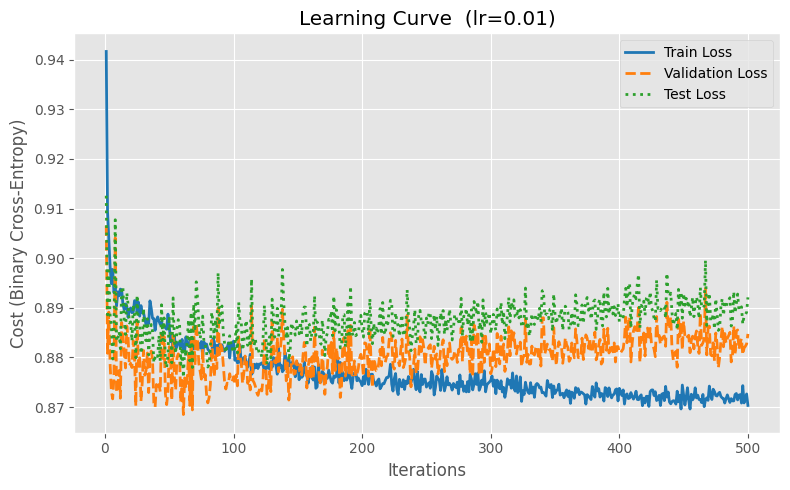

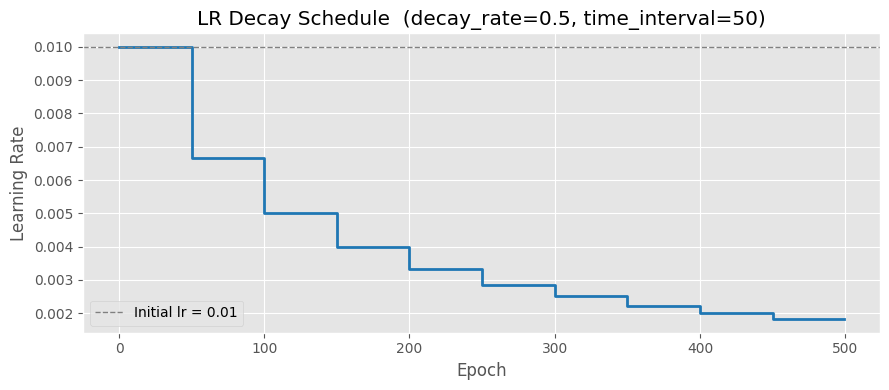

  lr start : 0.010000
  lr end   : 0.001818
  total reduction: 5.5x


In [56]:
learning_rate       = 0.01
num_iterations      = 500
thresh              = 0.4
Balancing_technique = "Original"  # Original | Oversampling | Undersampling 
BATCH_SIZE          = 256        # None=full-batch | int=mini-batch (e.g.256) | 1=SGD
optimizer           = "adam"      # gd | momentum | adam

USE_L2       = False   
L2_LAMBDA    = 0.01    
USE_L1       = False   
L1_LAMBDA    = 0.01    

USE_DROPOUT  = True   
# None → default 0.8 keep probability for all hidden layers
KEEP_PROB_DICT = None  # e.g. {1: 0.8, 2: 0.9} | None = 0.8 for all hidden layers

USE_LR_DECAY   = True    #   DECAY_RATE=0.5, TIME_INTERVAL=200 → lr ends ~0.0033  (gentle staircase)
DECAY_RATE     = 0.5     #   DECAY_RATE=0.1, TIME_INTERVAL=100 → lr ends ~0.0053  (very gentle)
TIME_INTERVAL  = 50     #   DECAY_RATE=1.0, TIME_INTERVAL=200 → lr ends ~0.0020  (moderate)

Gradient_checking = True
Show_cost = False

data_balancing_type = {
    'Original':      df,
    'Oversampling':  df_oversampled,
    'Undersampling': df_undersampled,
}

X_train, X_dev, X_test, Y_train, Y_dev, Y_test = load_dataset(
    data_balancing_type[Balancing_technique])

tracker_manual = EmissionsTracker(project_name='manual_model', log_level='error')

m_train         = X_train.shape[1]
effective_batch = m_train if BATCH_SIZE is None else BATCH_SIZE
print(f'\nBatch mode   : {"Full-batch" if BATCH_SIZE is None else ("SGD (batch=1)" if BATCH_SIZE == 1 else f"Mini-batch (size={BATCH_SIZE})")}')
print(f'Batches/epoch: {int(np.ceil(m_train / effective_batch))}')

_reg = []
if USE_L2:      _reg.append(f"L2 (λ={L2_LAMBDA})")
if USE_L1:      _reg.append(f"L1 (λ={L1_LAMBDA})")
if USE_DROPOUT: _reg.append(f"Dropout (keep_prob={KEEP_PROB_DICT or 0.8})")
print(f'Manual regularization: {", ".join(_reg) if _reg else "None"}')

layers     = [X_train.shape[0], 32, 16, 1]
parameters = intialization(layers)

tracker_manual.start()

parameters, costs_train, costs_val, costs_test, lr_history = models(
    X_train, Y_train, layers, optimizer, parameters,
    X_val=X_dev,   Y_val=Y_dev,
    X_test=X_test, Y_test=Y_test,
    lr=learning_rate,
    beta=0.9, beta1 = 0.9, beta2=0.999, epsilon=1e-8,
    num_iterations = num_iterations,
    batch_size = BATCH_SIZE,
    print_cost = Show_cost,
    pos_weight = manual_pos_weight, # 1.0 to turn off and manual_pos_weight to use it
    use_l2=USE_L2,           l2_lambda=L2_LAMBDA,
    use_l1=USE_L1,           l1_lambda=L1_LAMBDA,
    use_dropout=USE_DROPOUT, keep_prob_dict=KEEP_PROB_DICT,
    run_gradient_check = Gradient_checking,  
    use_lr_decay=USE_LR_DECAY, decay_rate=DECAY_RATE, time_interval=TIME_INTERVAL,
)

emissions_manual = tracker_manual.stop()
plot_costs(costs_train, costs_val, costs_test, learning_rate)
if USE_LR_DECAY:
    plot_lr_schedule(lr_history, learning_rate, DECAY_RATE, TIME_INTERVAL)

## Carbon Foot Print

To measure the model’s carbon footprint, we used CodeCarbon due to its simplicity of implementation. However, it is not the most accurate or efficient tool for this purpose. As observed, the tool was unable to properly estimate the carbon footprint. This limitation is likely due to the training environment, which was conducted on a dual-boot system running Linux, preventing the tool from correctly detecting and utilizing the GPU.

## Metrics :

The performance of the models will be evaluated using the following metrics: accuracy, precision, recall, F1-score, and AUC-ROC.

For this project, particular emphasis will be placed on recall and AUC-ROC. Recall is prioritized because it measures the model’s ability to correctly identify diabetic patients, which is critical in a medical context where failing to detect a positive case can have serious consequences. AUC-ROC, on the other hand, provides a comprehensive assessment of the model’s performance across both classes, offering a global view of its discriminative capability.



── Train Metrics ──
  Accuracy  : 0.6340
  Precision : 0.2621
  Recall    : 0.8970
  F1 Score  : 0.4057
  AUC-ROC   : 0.8330

── Dev Metrics ──
  Accuracy  : 0.6322
  Precision : 0.2609
  Recall    : 0.8896
  F1 Score  : 0.4035
  AUC-ROC   : 0.8281

── Test Metrics ──
  Accuracy  : 0.6296
  Precision : 0.2580
  Recall    : 0.8870
  F1 Score  : 0.3998
  AUC-ROC   : 0.8246
Manual Model Carbon Footprint
  CO2 equivalent : 0.3256 g CO2eq
  CO2 equivalent : 0.000326 kg CO2eq


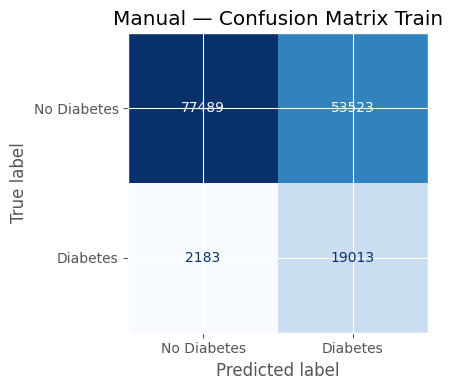

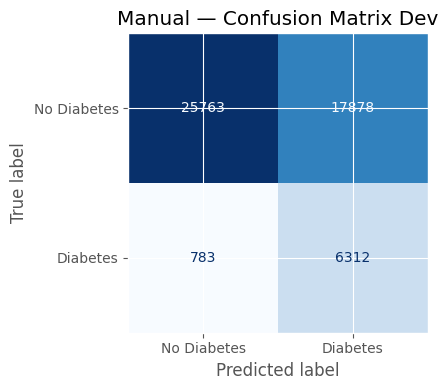

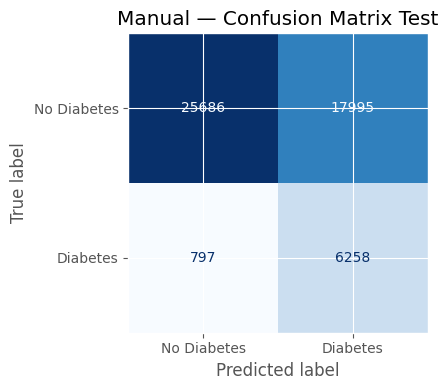

In [57]:
def predict(X, parameters, threshold):
    AL, _ = L_model_forward(X, parameters)
    return (AL >= threshold).astype(int)



def evaluate(X, Y, parameters, label='Set', threshold=0.5):
    AL, _ = L_model_forward(X, parameters)
    Y_prob = AL.flatten()                          # raw probabilities for AUC
    Y_pred = (Y_prob >= threshold).astype(int)
    Y_true = Y.flatten().astype(int)

    TP = np.sum((Y_pred == 1) & (Y_true == 1))
    TN = np.sum((Y_pred == 0) & (Y_true == 0))
    FP = np.sum((Y_pred == 1) & (Y_true == 0))
    FN = np.sum((Y_pred == 0) & (Y_true == 1))

    accuracy  = (TP + TN) / len(Y_true)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    auc       = roc_auc_score(Y_true, Y_prob) if len(np.unique(Y_true)) > 1 else 0.0

    print(f'\n── {label} Metrics ──')
    print(f'  Accuracy  : {accuracy:.4f}')
    print(f'  Precision : {precision:.4f}')
    print(f'  Recall    : {recall:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'  AUC-ROC   : {auc:.4f}')

    return Y_pred, Y_true, Y_prob


def plot_confusion_matrix(Y_true, Y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(Y_true, Y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


train_pred, train_true, train_prob = evaluate(X_train, Y_train, parameters, label='Train', threshold = thresh)
dev_pred,   dev_true,   dev_prob   = evaluate(X_dev,   Y_dev,   parameters, label='Dev', threshold = thresh)
test_pred,  test_true,  test_prob  = evaluate(X_test,  Y_test,  parameters, label='Test', threshold = thresh)

print(f'Manual Model Carbon Footprint')
print(f'  CO2 equivalent : {emissions_manual*1000:.4f} g CO2eq')
print(f'  CO2 equivalent : {emissions_manual:.6f} kg CO2eq')

plot_confusion_matrix(train_true, train_pred, title='Manual — Confusion Matrix Train')
plot_confusion_matrix(dev_true,   dev_pred,   title='Manual — Confusion Matrix Dev')
plot_confusion_matrix(test_true,  test_pred,  title='Manual — Confusion Matrix Test')

In [58]:
# import numpy as np
# import pickle

# # Save weights and biases (parameters dict → .npz file)
# arrays_to_save = {}
# L = len(parameters) // 2
# for l in range(1, L + 1):
#     arrays_to_save[f"W{l}"] = parameters[f"W{l}"]
#     arrays_to_save[f"b{l}"] = parameters[f"b{l}"]

# np.savez("/home/yacine/Documents/WorkSpace/CESI/S7/DeepLearning/Deployment/Backend/params.npz", **arrays_to_save)

# # Save the scaler (it holds the min/max from training data)
# with open("/home/yacine/Documents/WorkSpace/CESI/S7/DeepLearning/Deployment/Backend/scaler.pkl", "wb") as f:
#     pickle.dump(scaler, f)

# print("Saved params.npz and scaler.pkl")

In [59]:
from tensorflow.keras import layers, regularizers


KERAS_USE_L2      = False   # L2 kernel regularization on all Dense layers
KERAS_L2_LAMBDA   = 0.01    # λ for Keras L2

KERAS_USE_L1      = False   # L1 kernel regularization on all Dense layers
KERAS_L1_LAMBDA   = 0.01    # λ for Keras L1

KERAS_USE_DROPOUT = True   # Dropout after each hidden Dense layer
KERAS_KEEP_PROB   = 0.8     # Keep probability (dropout rate = 1 - keep_prob)



def _build_keras_regularizer():
    """Return the appropriate Keras regularizer from the flags above."""
    if KERAS_USE_L2 and KERAS_USE_L1:
        return regularizers.l1_l2(l1=KERAS_L1_LAMBDA, l2=KERAS_L2_LAMBDA)
    elif KERAS_USE_L2:
        return regularizers.l2(KERAS_L2_LAMBDA)
    elif KERAS_USE_L1:
        return regularizers.l1(KERAS_L1_LAMBDA)
    return None

keras_regularizer  = _build_keras_regularizer()
keras_dropout_rate = 1.0 - KERAS_KEEP_PROB

tf.random.set_seed(42)

# Build model layers dynamically based on regularization flags
_keras_layers = [layers.Input(shape=(X_train.shape[0],))]

# Hidden layer 1
_keras_layers.append(
    layers.Dense(32, activation='relu',
                 kernel_initializer=keras.initializers.HeNormal(seed=42),
                 kernel_regularizer=keras_regularizer))
_keras_layers.append(
    layers.Dense(16, activation='relu',
                 kernel_initializer=keras.initializers.HeNormal(seed=42),
                 kernel_regularizer=keras_regularizer))
if KERAS_USE_DROPOUT:
    _keras_layers.append(layers.Dropout(rate=keras_dropout_rate, seed=42))


# Output layer
_keras_layers.append(layers.Dense(1, activation='sigmoid'))

keras_model_rand = keras.Sequential(_keras_layers, name='diabetes_keras_rand')

tracker_keras = EmissionsTracker(project_name='keras_model', log_level='error')
tracker_keras.start()

keras_model_rand.compile(
    optimizer=keras.optimizers.Adam(learning_rate),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

emissions_keras = tracker_keras.stop()

_kreg = []
if KERAS_USE_L2:      _kreg.append(f"L2 (λ={KERAS_L2_LAMBDA})")
if KERAS_USE_L1:      _kreg.append(f"L1 (λ={KERAS_L1_LAMBDA})")
if KERAS_USE_DROPOUT: _kreg.append(f"Dropout (keep={KERAS_KEEP_PROB})")
print(f'Keras regularization: {", ".join(_kreg) if _kreg else "None"}')

keras_model_rand.summary()


2026-05-03 23:44:47.439339: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-03 23:44:47.454460: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Keras regularization: Dropout (keep=0.8)
Model: "diabetes_keras_rand"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                576       
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dropout (Dropout)           (None, 16)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 17        
                                                                 
Total params: 1121 (4.38 KB)
Trainable params: 1121 (4.38 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


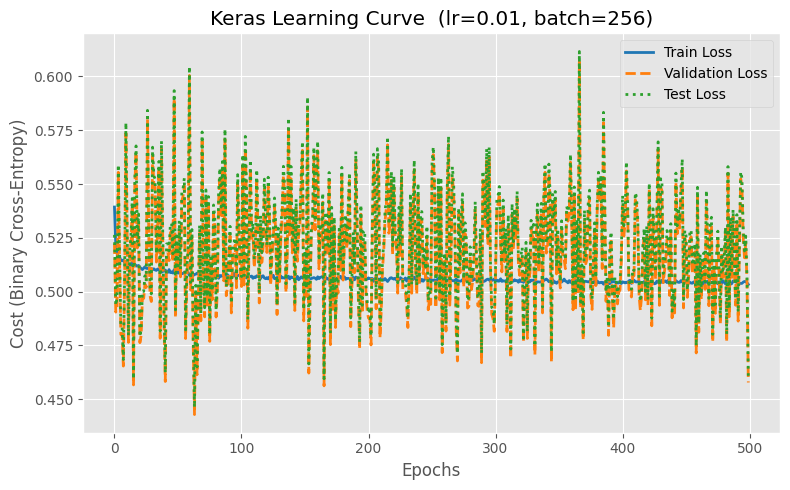

In [60]:
keras_batch = m_train if BATCH_SIZE is None else BATCH_SIZE

class TestLossCallback(tf.keras.callbacks.Callback):
    def __init__(self, X_test, Y_test):
        super().__init__()
        self.X_test = X_test
        self.Y_test = Y_test
        self.test_losses = []
    def on_epoch_end(self, epoch, logs=None):
        loss = self.model.evaluate(self.X_test, self.Y_test, verbose=0)[0]
        self.test_losses.append(loss)

test_cb = TestLossCallback(X_test.T, Y_test.T)

history = keras_model_rand.fit(
    X_train.T, Y_train.T,
    validation_data=(X_dev.T, Y_dev.T),
    epochs=num_iterations,
    batch_size=keras_batch,
    callbacks=[test_cb],
    class_weight=class_weight_dict,
    verbose=0
)

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],     label='Train Loss',      linewidth=2, color='tab:blue')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--', color='tab:orange')
plt.plot(test_cb.test_losses,         label='Test Loss',       linewidth=2, linestyle=':',  color='tab:green')
plt.ylabel('Cost (Binary Cross-Entropy)')
plt.xlabel('Epochs')
plt.title(f'Keras Learning Curve  (lr={learning_rate}, batch={keras_batch})')
plt.legend()
plt.tight_layout()
plt.show()


In [61]:
def evaluate_keras(model, X, Y, label='Set',threshold=0.5):
    Y_prob = model.predict(X.T, verbose=0).flatten()
    Y_pred = (Y_prob >= threshold).astype(int)
    Y_true = Y.flatten().astype(int)

    TP = np.sum((Y_pred == 1) & (Y_true == 1))
    TN = np.sum((Y_pred == 0) & (Y_true == 0))
    FP = np.sum((Y_pred == 1) & (Y_true == 0))
    FN = np.sum((Y_pred == 0) & (Y_true == 1))

    accuracy  = (TP + TN) / len(Y_true)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0.0
    auc       = roc_auc_score(Y_true, Y_prob) if len(np.unique(Y_true)) > 1 else 0.0

    print(f'\n── Keras {label} Metrics ──')
    print(f'  Accuracy  : {accuracy:.4f}')
    print(f'  Precision : {precision:.4f}')
    print(f'  Recall    : {recall:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'  AUC-ROC   : {auc:.4f}')

    return Y_pred, Y_true, Y_prob


keras_train_pred, keras_train_true, keras_train_prob = evaluate_keras(keras_model_rand, X_train, Y_train, label='Train', threshold=thresh)
keras_dev_pred,   keras_dev_true,   keras_dev_prob   = evaluate_keras(keras_model_rand, X_dev,   Y_dev,   label='Dev', threshold=thresh)
keras_test_pred,  keras_test_true,  keras_test_prob  = evaluate_keras(keras_model_rand, X_test,  Y_test,  label='Test', threshold=thresh)
print(f'Keras Model Carbon Footprint')
print(f'  CO2 equivalent : {emissions_keras*1000:.4f} g CO2eq')
print(f'  CO2 equivalent : {emissions_keras:.6f} kg CO2eq')


── Keras Train Metrics ──
  Accuracy  : 0.6970
  Precision : 0.2930
  Recall    : 0.8319
  F1 Score  : 0.4333
  AUC-ROC   : 0.8337

── Keras Dev Metrics ──
  Accuracy  : 0.6937
  Precision : 0.2907
  Recall    : 0.8262
  F1 Score  : 0.4300
  AUC-ROC   : 0.8251

── Keras Test Metrics ──
  Accuracy  : 0.6931
  Precision : 0.2885
  Recall    : 0.8231
  F1 Score  : 0.4273
  AUC-ROC   : 0.8215
Keras Model Carbon Footprint
  CO2 equivalent : 0.0008 g CO2eq
  CO2 equivalent : 0.000001 kg CO2eq


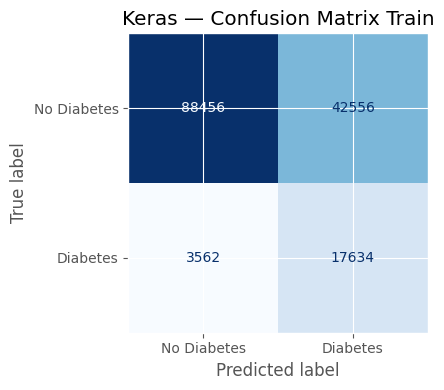

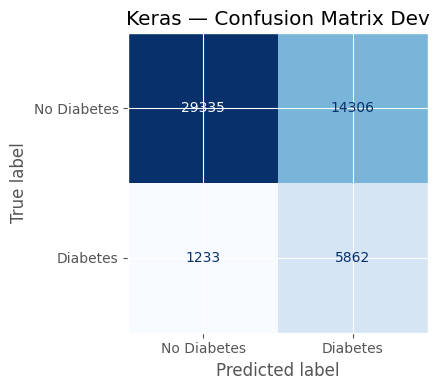

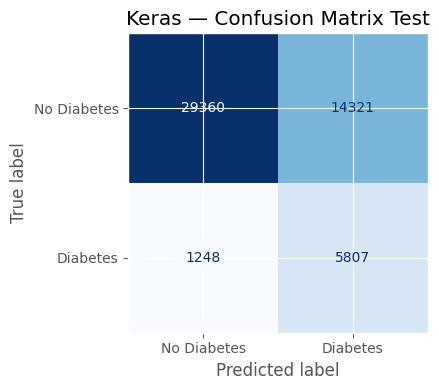

In [62]:
plot_confusion_matrix(keras_train_true, keras_train_pred, title='Keras — Confusion Matrix Train')
plot_confusion_matrix(keras_dev_true,   keras_dev_pred,   title='Keras — Confusion Matrix Dev')
plot_confusion_matrix(keras_test_true,  keras_test_pred,  title='Keras — Confusion Matrix Test')


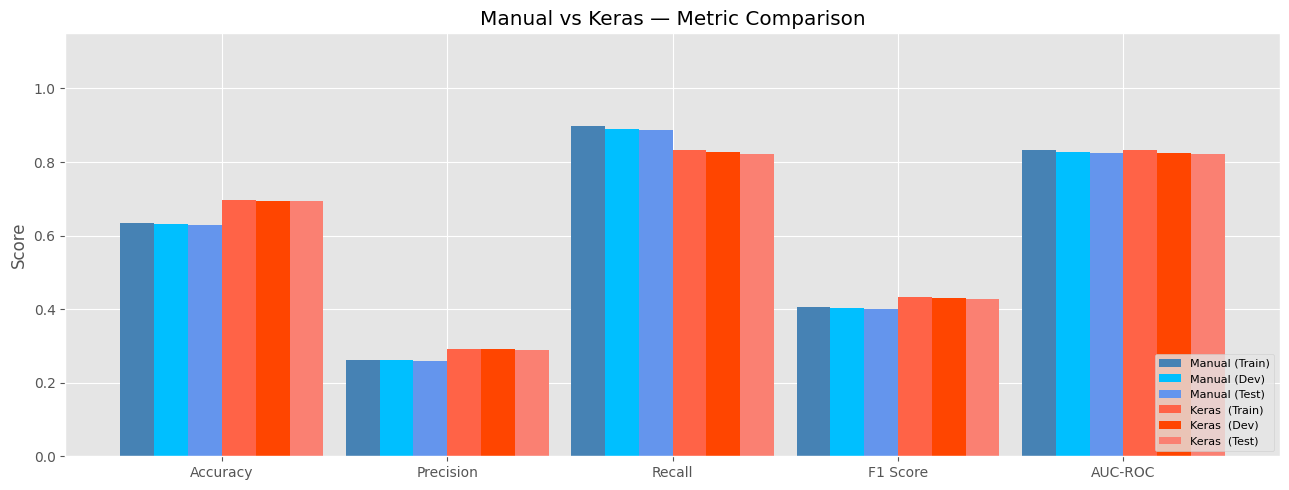

In [63]:
def get_metrics(Y_true, Y_pred, Y_prob=None):
    TP = np.sum((Y_pred == 1) & (Y_true == 1))
    TN = np.sum((Y_pred == 0) & (Y_true == 0))
    FP = np.sum((Y_pred == 1) & (Y_true == 0))
    FN = np.sum((Y_pred == 0) & (Y_true == 1))
    acc  = (TP + TN) / len(Y_true)
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    rec  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0.0
    auc  = roc_auc_score(Y_true, Y_prob) if (Y_prob is not None and len(np.unique(Y_true)) > 1) else 0.0
    return acc, prec, rec, f1, auc

m_manual_train = get_metrics(train_true, train_pred, train_prob)
m_manual_dev   = get_metrics(dev_true,   dev_pred,   dev_prob)
m_manual_test  = get_metrics(test_true,  test_pred,  test_prob)
m_keras_train  = get_metrics(keras_train_true, keras_train_pred, keras_train_prob)
m_keras_dev    = get_metrics(keras_dev_true,   keras_dev_pred,   keras_dev_prob)
m_keras_test   = get_metrics(keras_test_true,  keras_test_pred,  keras_test_prob)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
x = np.arange(len(metrics_names))
width = 0.15

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - 2.5*width, m_manual_train, width, label='Manual (Train)', color='steelblue')
ax.bar(x - 1.5*width, m_manual_dev,   width, label='Manual (Dev)',   color='deepskyblue')
ax.bar(x - 0.5*width, m_manual_test,  width, label='Manual (Test)',  color='cornflowerblue')
ax.bar(x + 0.5*width, m_keras_train,  width, label='Keras  (Train)', color='tomato')
ax.bar(x + 1.5*width, m_keras_dev,    width, label='Keras  (Dev)',   color='orangered')
ax.bar(x + 2.5*width, m_keras_test,   width, label='Keras  (Test)',  color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Manual vs Keras — Metric Comparison')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


## ROC Curves & AUC

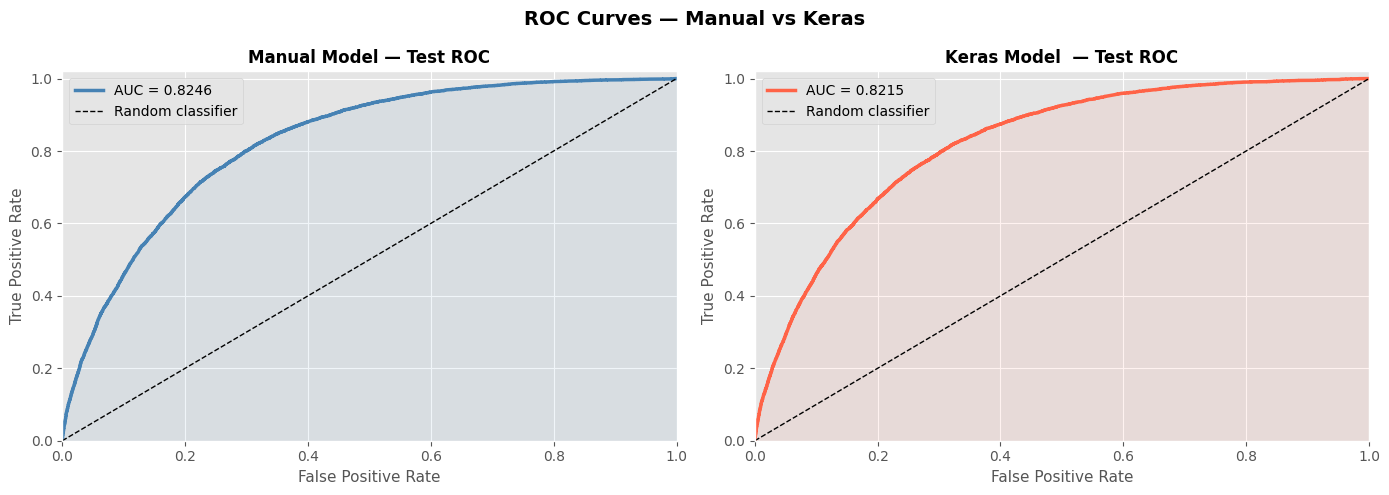

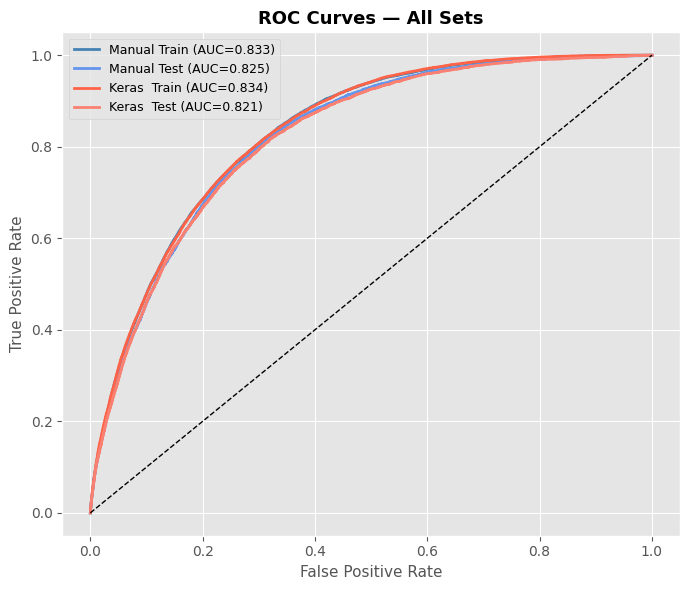

In [64]:
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y_true, y_prob, title, color) in zip(axes, [
    (test_true,       test_prob,       'Manual Model — Test ROC',  'steelblue'),
    (keras_test_true, keras_test_prob, 'Keras Model  — Test ROC',  'tomato'),
]):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate',  fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle('ROC Curves — Manual vs Keras', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Overlay both on one plot for direct comparison ───────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
for y_true, y_prob, label, color in [
    (train_true,      train_prob,      f'Manual Train (AUC={auc(roc_curve(train_true, train_prob)[:2][::-1][0], roc_curve(train_true, train_prob)[:2][::-1][1]):.3f})', 'steelblue'),
    (test_true,       test_prob,       f'Manual Test',  'cornflowerblue'),
    (keras_train_true,keras_train_prob,f'Keras  Train', 'tomato'),
    (keras_test_true, keras_test_prob, f'Keras  Test',  'salmon'),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{label.split("(")[0].strip()} (AUC={roc_auc:.3f})', color=color)

ax.plot([0,1],[0,1],'k--',linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate',  fontsize=11)
ax.set_title('ROC Curves — All Sets', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## False Negatives  Diabetic Patients Missed by Each Model

In [65]:
print("=" * 60)
print("  PATIENTS WITH DIABETES MISSED BY EACH MODEL (Test Set)")
print("=" * 60)

# Rebuild test indices (must match load_dataset seed/split)
_dataset_arr = np.array(data_balancing_type[Balancing_technique], dtype=np.float64)
np.random.seed(42)
_indices    = np.random.permutation(len(_dataset_arr))
_n          = len(_dataset_arr)
_train_end  = int(0.60 * _n)
_val_end    = _train_end + int(0.20 * _n)
_test_idx   = _indices[_val_end:]

df_test_records = data_balancing_type[Balancing_technique].iloc[_test_idx].reset_index(drop=True)
df_test_records['True_Label']   = test_true
df_test_records['Manual_Pred']  = test_pred
df_test_records['Manual_Prob']  = np.round(test_prob, 4)
df_test_records['Keras_Pred']   = keras_test_pred
df_test_records['Keras_Prob']   = np.round(keras_test_prob, 4)

# False Negatives per model
manual_FN = df_test_records[
    (df_test_records['True_Label'] == 1) & (df_test_records['Manual_Pred'] == 0)
].copy()

keras_FN = df_test_records[
    (df_test_records['True_Label'] == 1) & (df_test_records['Keras_Pred'] == 0)
].copy()

both_FN = df_test_records[
    (df_test_records['True_Label'] == 1) &
    (df_test_records['Manual_Pred'] == 0) &
    (df_test_records['Keras_Pred']  == 0)
].copy()



display_cols = [c for c in ['Diabetes_binary','HighBP','HighChol','BMI','Age','GenHlth',
                             'Manual_Prob','Keras_Prob'] if c in df_test_records.columns]



  PATIENTS WITH DIABETES MISSED BY EACH MODEL (Test Set)


## Full Metrics Comparison Table

In [69]:
# ── Full Metrics Comparison Table ───────────────────────────────────────────
import pandas as pd

metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']

comparison_data = {
    'Metric'        : metric_labels,
    'Manual Train'  : [f'{v:.4f}' for v in m_manual_train],
    'Manual Dev'    : [f'{v:.4f}' for v in m_manual_dev],
    'Manual Test'   : [f'{v:.4f}' for v in m_manual_test],
    'Keras  Train'  : [f'{v:.4f}' for v in m_keras_train],
    'Keras  Dev'    : [f'{v:.4f}' for v in m_keras_dev],
    'Keras  Test'   : [f'{v:.4f}' for v in m_keras_test],
}

df_comparison = pd.DataFrame(comparison_data).set_index('Metric')

# Pretty-print
# print("\n" + "="*72)
# print("         MANUAL vs KERAS — FULL METRICS COMPARISON TABLE")
# print("="*72)
# print(df_comparison.to_string())
# print("="*72)

# Styled HTML display (renders in Jupyter)
styled = (
    df_comparison.style
    .set_caption("Manual vs Keras — Full Metrics Comparison")
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '8px')]},
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '6px 14px')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f0f4f8')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#d6eaf8')]},
    ])
    .apply(lambda col: [
        'background-color: #d5f5e3' if float(v) >= 0.75
        else ('background-color: #fdebd0' if float(v) >= 0.60
              else 'background-color: #fadbd8')
        for v in col
    ], subset=['Manual Train','Manual Dev','Manual Test',
               'Keras  Train','Keras  Dev', 'Keras  Test'])
)
display(styled)


,Manual Train,Manual Dev,Manual Test,Keras Train,Keras Dev,Keras Test
Metric,,,,,,
Accuracy,0.6340,0.6322,0.6296,0.6970,0.6937,0.6931
Precision,0.2621,0.2609,0.2580,0.2930,0.2907,0.2885
Recall,0.8970,0.8896,0.8870,0.8319,0.8262,0.8231
F1 Score,0.4057,0.4035,0.3998,0.4333,0.4300,0.4273
AUC-ROC,0.8330,0.8281,0.8246,0.8337,0.8251,0.8215


<a name='6'></a>

# Error Analysis

This section presents the error analysis conducted across multiple configurations and iterative experiments. The process began with the training of a baseline model, implemented using a simple architecture and without the application of any advanced techniques.

**Used Optimizer :** gradient decent Default SGD in keras

**leraning rate :** 0.01

**Layers architecture :** [17, 64, 1]

**Number of iterations :** 1000

**BATCH :** none

**Manual Model :**
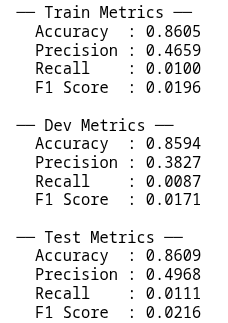
**Keras Model :**
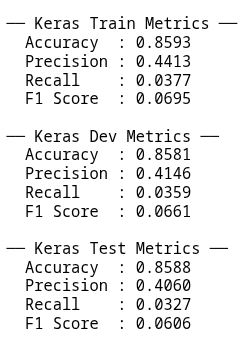
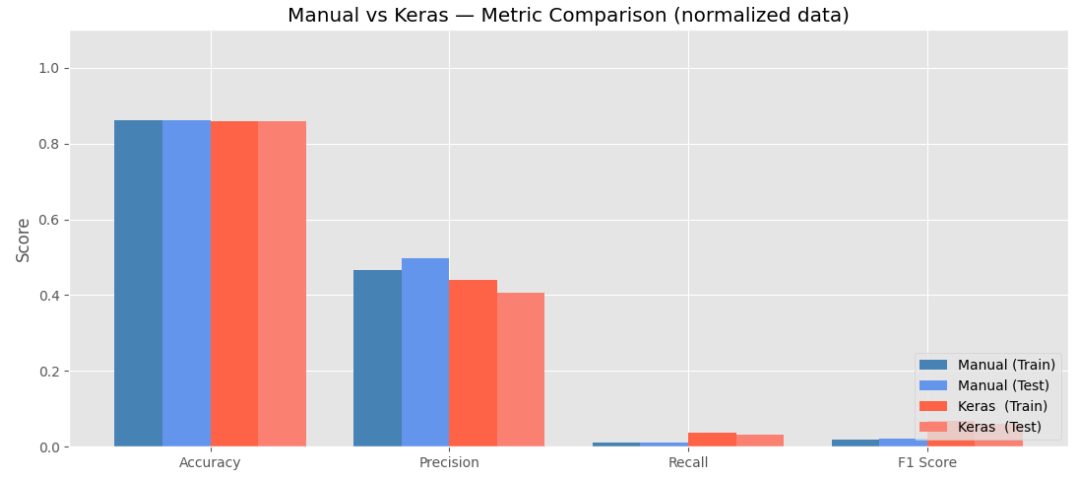

**Used Optimizer :** gradient decent Default SGD in keras

**leraning rate :** 0.01

**Layers architecture :** [17, 128, 64, 64, 1]

**Number of iterations :** 500

**BATCH :** none

**Manual Model :**
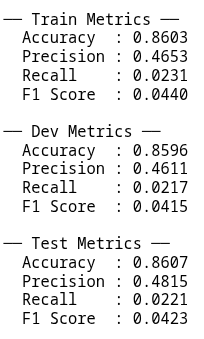
**Keras Model :**
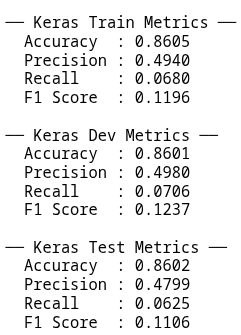

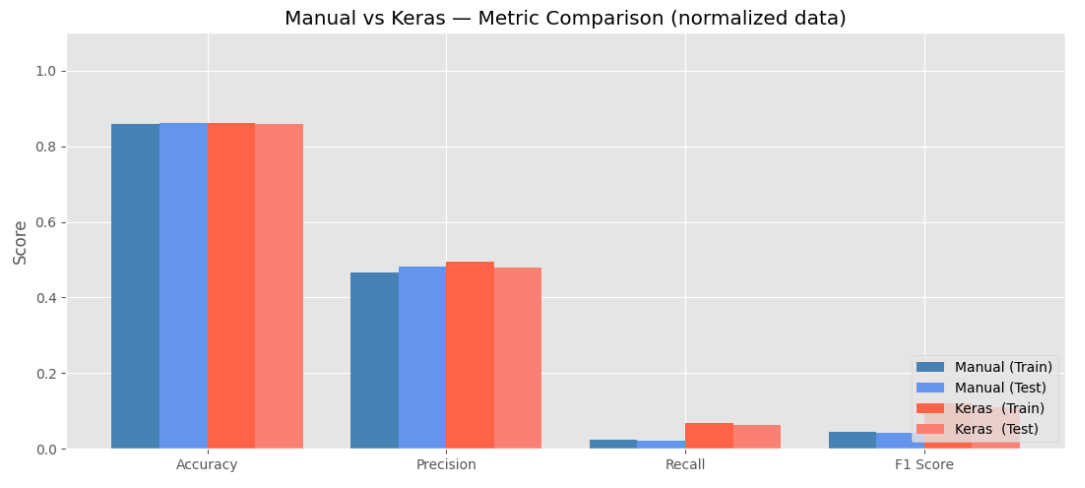

**Used Optimizer :** gradient decent Default SGD in keras

**leraning rate :** 0.01

**Layers architecture :** [17, 128, 64, 64, 1]

**Number of iterations :** 200

**BATCH :** 6024 (Batches/epoch: 26) 

**Manual Model :**
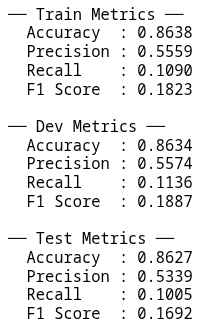

**Keras Model :**
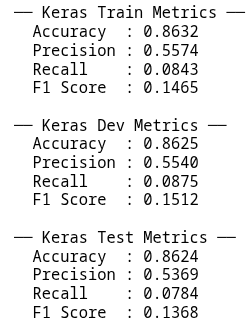

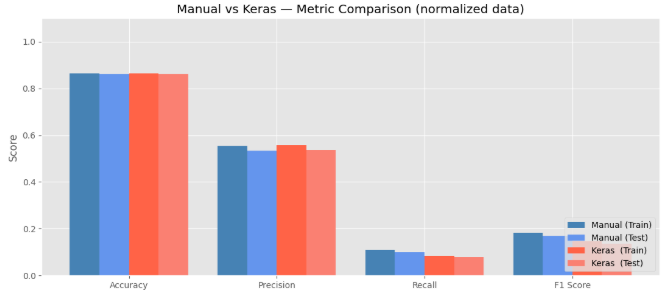

## Primary Error Analysis

As observed, the accuracy is approximately 80%, which suggests a clear indication of underfitting. More importantly, the consistently low F1-score and recall across all configurations point to a significant class imbalance issue. Specifically, the dataset contains substantially more non-diabetic cases than diabetic ones.

This imbalance is further illustrated in the previous figure, where the class distribution reveals an imbalance ratio of 6.18, which is considerably high. To address this issue, it is necessary to apply the previously discussed data balancing techniques in order to improve the model’s ability to correctly identify diabetic cases.

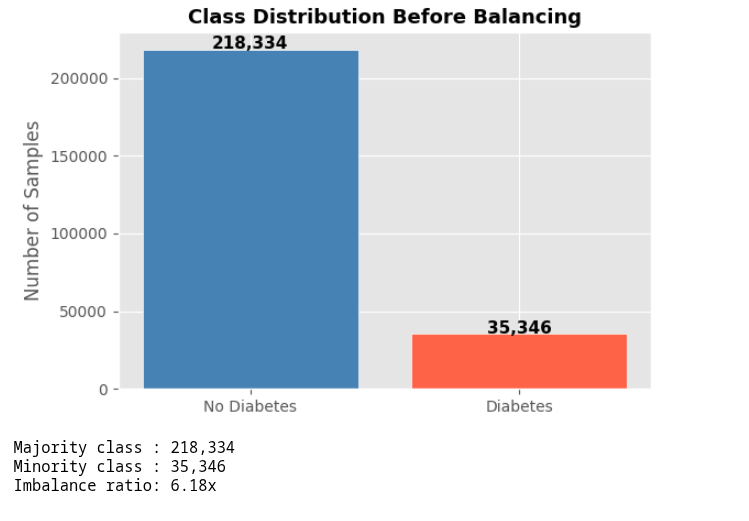

## Data Balancing

### Oversampling

**Used Optimizer :** gradient decent Default SGD in keras

**leraning rate :** 0.01

**Layers architecture :** [512, 256, 128, 128, 64, 64, 32, 16, 1]

**Number of iterations :** 300

**Balancing_technique :** Oversampling   

    
**BATCH :** None

**Manual Model :**
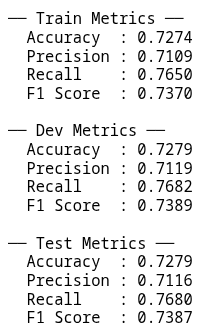

**Keras Model :**
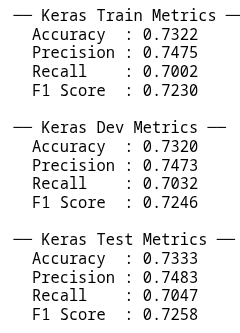


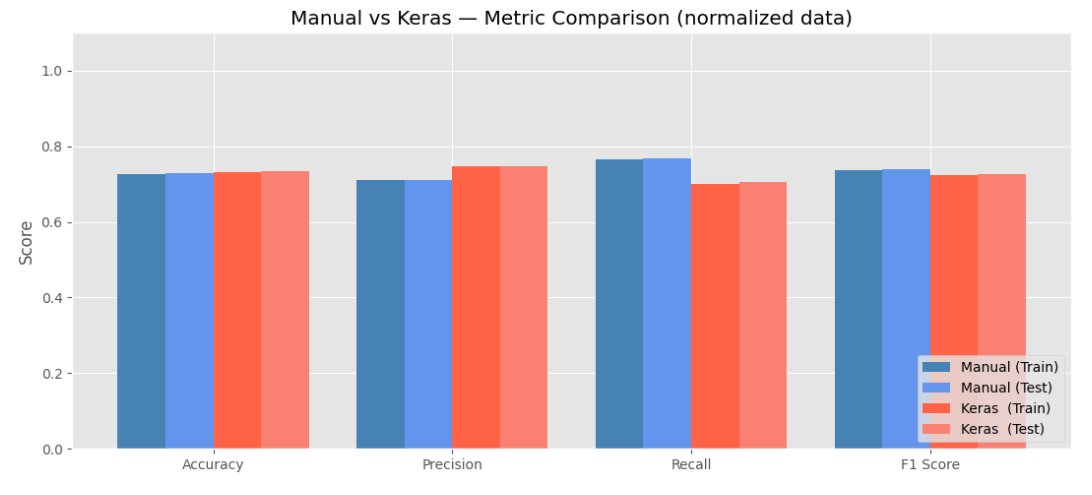

### Undersampling

**Used Optimizer :** gradient decent Default SGD in keras

**leraning rate :** 0.01

**Layers architecture :** [512, 256, 128, 128, 64, 64, 32, 16, 1]

**Number of iterations :** 300

**Balancing_technique :** Undersampling   

    
**BATCH :** 6024 (Batches/epoch: 26) 

**Manual Model :**
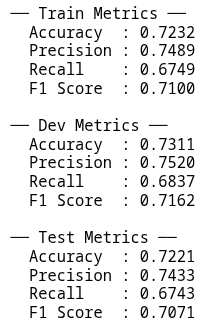

**Keras Model :**
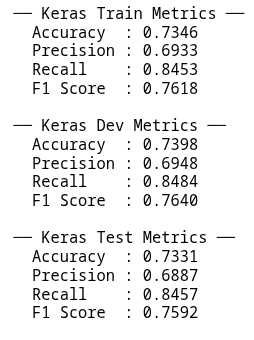

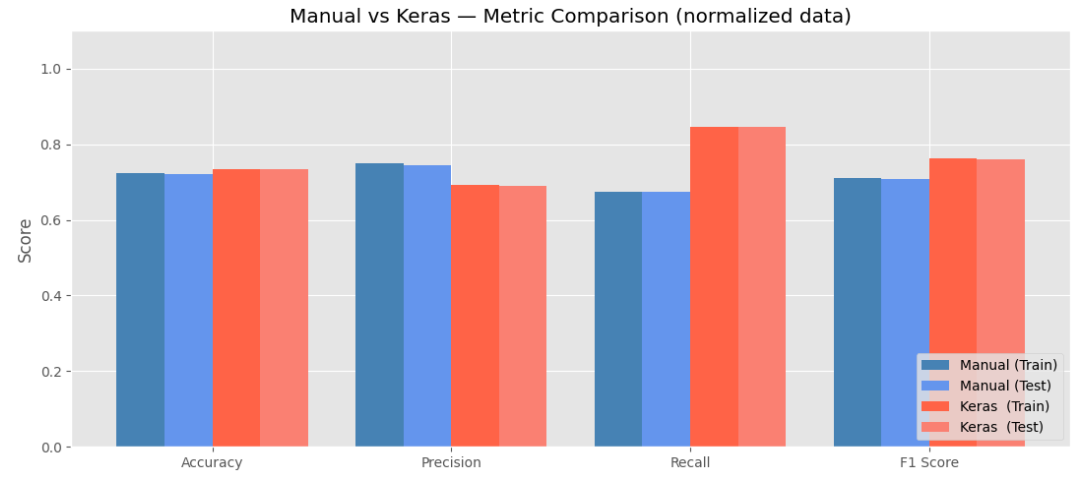

## Class weights

**Used Optimizer :** gradient decent Default SGD in keras

**leraning rate :** 0.01

**Layers architecture :** [512, 256, 128, 128, 64, 64, 32, 16, 1]

**Number of iterations :** 300

**Balancing_technique :** Class weights   

    
**BATCH :** None

**Manual Model :**
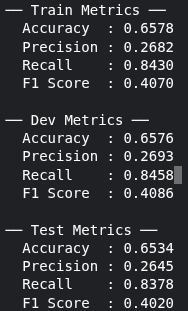

**Keras Model :**
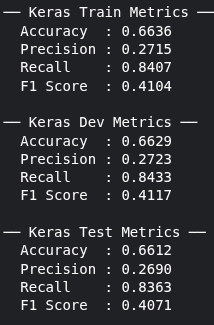

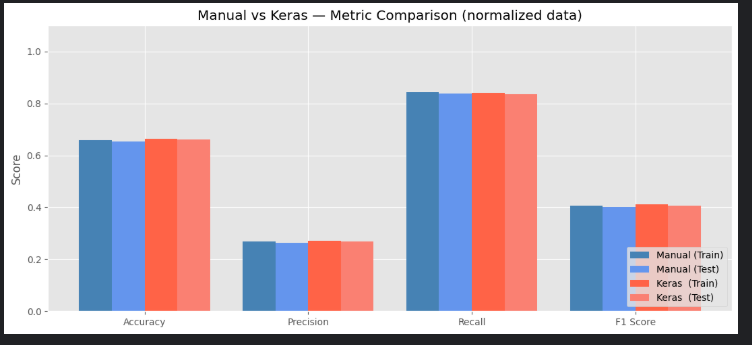

## Optimizing the Parmeters

As observed, the application of the data balancing techniques led to improvements in key performance metrics, including recall, F1-score, and precision. However, the models still exhibit signs of underfitting. To address this limitation, the next step will involve the application of optimization techniques to enhance model performance.

### Adam

**Used Optimizer :** Adam

**leraning rate :** 0.01

**Layers architecture :** [512, 256, 128, 128, 64, 64, 32, 16, 1]

**Number of iterations :** 300

**Balancing_technique :** None   
    
**BATCH :** None

**Manual Model :**
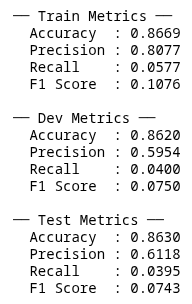

**Keras Model :**
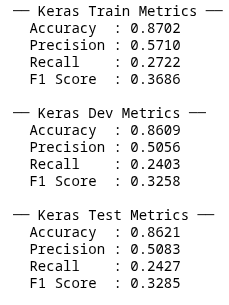

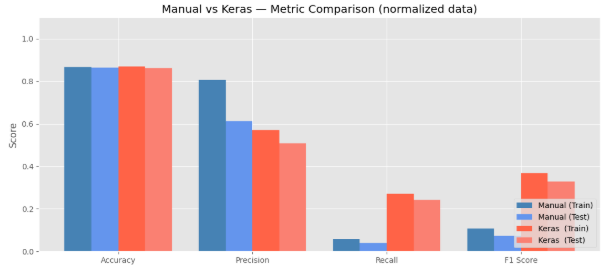

**Used Optimizer :** Adam

**leraning rate :** 0.01

**Layers architecture :** [512, 256, 128, 128, 64, 64, 32, 16, 1]

**Number of iterations :** 200

**Balancing_technique :** Undersampling   
    
**BATCH :** None

**Manual Model :**
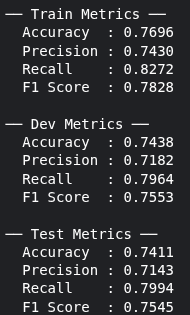

**Keras Model :**
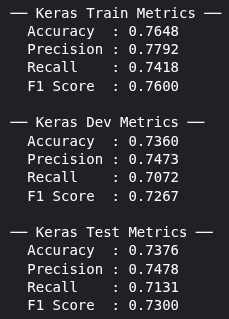

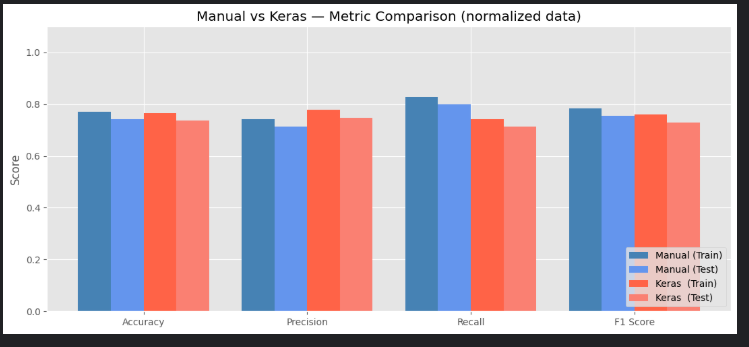

**Used Optimizer :** Adam

**leraning rate :** 0.01

**Layers architecture :** [512, 256, 128, 128, 64, 64, 32, 16, 1]

**Number of iterations :** 300

**Balancing_technique :** Oversampling   
    
**BATCH :** None

**Manual Model :**
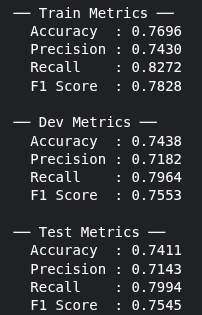

**Keras Model :**
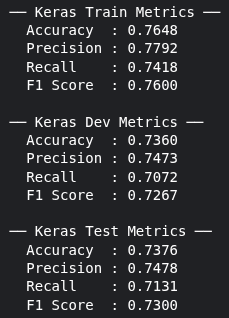

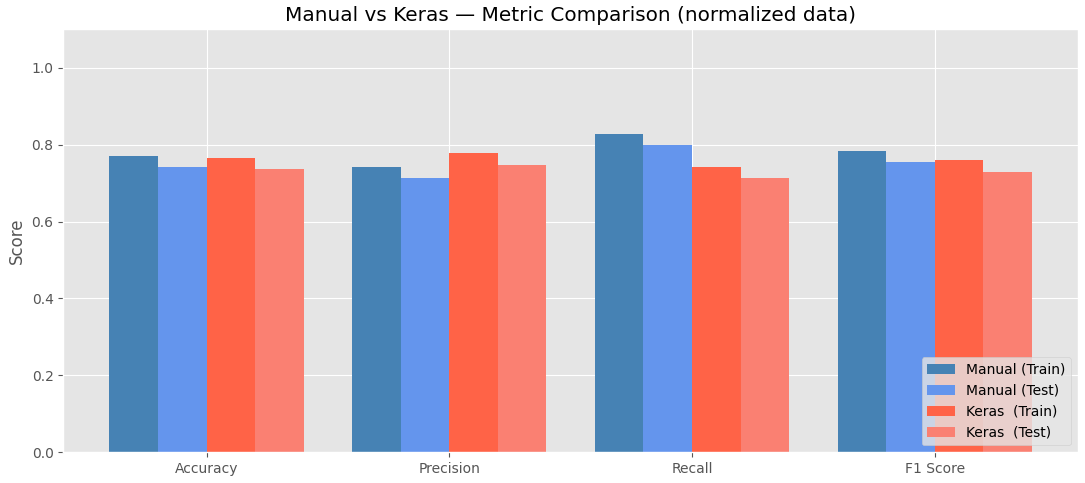

## Different Configurations

As observed, the application of optimization techniques resulted in only a slight improvement in model performance. This suggests that the issue may lie in the model configuration and hyperparameter tuning. Therefore, the next step will be to explore and evaluate multiple configurations in order to address the underfitting problem.

**Used Optimizer :** Adam

**leraning rate :** 0.01

**Layers architecture for manual model :** [17, 128, 64, 64, 1]


    
**Number of iterations :** 1000

**Balancing_technique :** Class Weights   
    
**BATCH :** 78%

**TRESHOLD :** 0.4

**Used Optimizer :** Adam

**leraning rate :** 0.001

**Layers architecture for manual model :** [17, 128, 64, 64, 1]

**Layers architecture for keras model :** [17, 128, 64, 32, 1]

    
**Number of iterations :** 1000

**Balancing_technique :** Class Weights   
    
**BATCH :** 256

**TRESHOLD :** 0.4

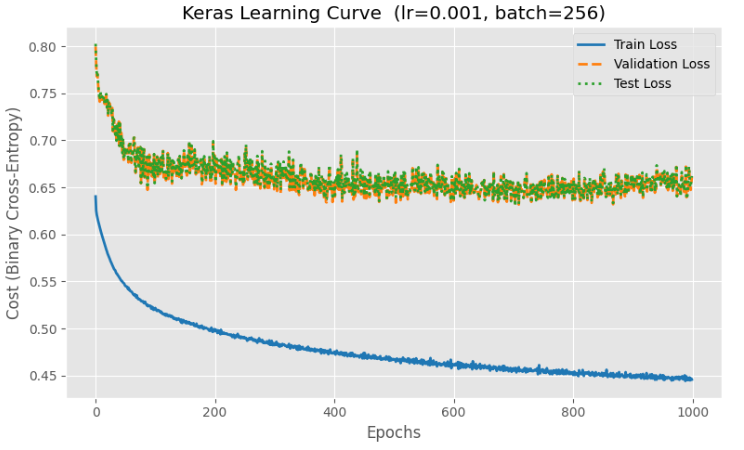

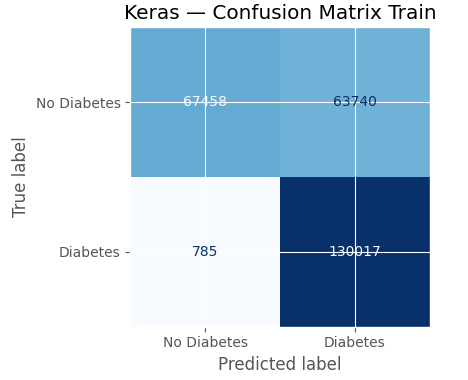
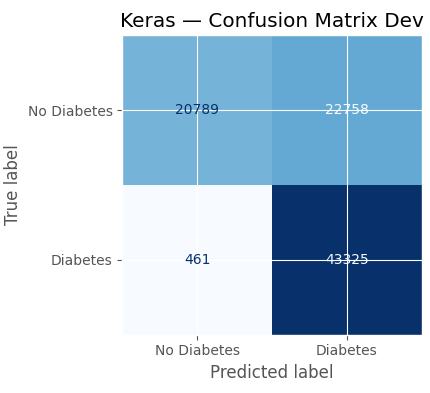
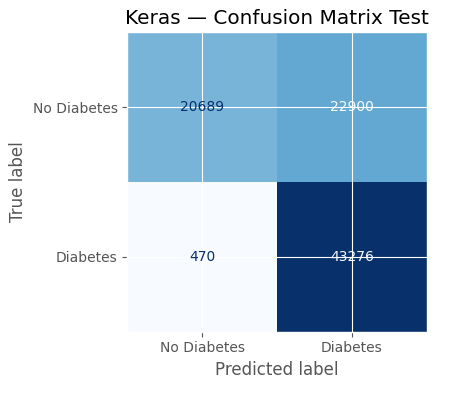

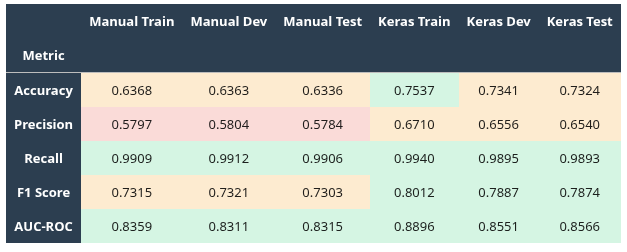
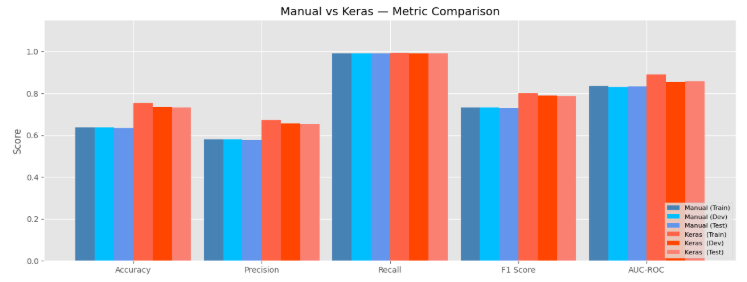

# Regularization

After several iterations with different configurations, improved results were achieved; however, the performance remained suboptimal due to the onset of overfitting. As evidenced by the previous metrics and loss curves, the models are clearly overfitting. To address this issue, regularization techniques will be applied to improve generalization.

**Used Optimizer :** Adam

**leraning rate :** 0.001

**Layers architecture   :** [17, 128, 64, 64, 1]

**Regualrization :** L2 Regualrization, DropOut 
 
**Number of iterations :** 1000

**Balancing_technique :** Class Weights   
    
**BATCH :** 256

**TRESHOLD :** 0.4

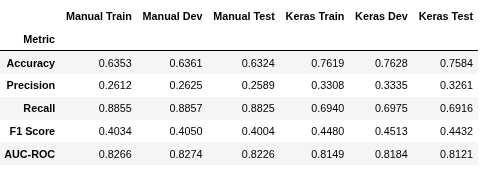

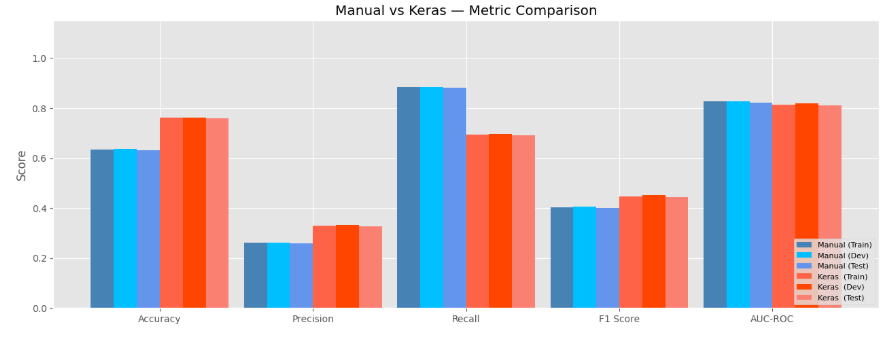

# Conclusion

In Conclusion we were able to improve the models till achiving overfiting, but we weren't able to fix the Overfiting because of the time that took us for different configuration to achieve this result, so know we need to continue trainig the models with the regularization technique